In [4]:
import pandas as pd
import numpy as np

In [5]:
# Custom functions
from core.demand_calculations import *
from utils.visualisations import plot_metal_demand_facets, plot_metal_demand_stackplots, plot_masse_stats_per_clas

# NRJ

## Capacity technology data

In [6]:
cap_tech_df = pd.read_excel(r'data/data.xlsx', sheet_name='ELEC_CAP_TECH')
mi_df = pd.read_excel(r'data/data.xlsx', sheet_name='MI')

In [7]:
cap_tech_can_df = cap_tech_df[cap_tech_df['Region'] == 'Canada']
cap_tech_can_df

,Scenario,Region,Variable,Year,Value,Unit
775,Canada Net-zero,Canada,Battery Storage,2020,95.0,MW
776,Canada Net-zero,Canada,Battery Storage,2021,95.0,MW
777,Canada Net-zero,Canada,Battery Storage,2022,140.0,MW
778,Canada Net-zero,Canada,Battery Storage,2023,140.0,MW
779,Canada Net-zero,Canada,Battery Storage,2024,140.0,MW
...,...,...,...,...,...,...
9481,Global Net-zero,Canada,Uranium SMR,2046,22671.0,MW
9482,Global Net-zero,Canada,Uranium SMR,2047,22996.0,MW
9483,Global Net-zero,Canada,Uranium SMR,2048,23311.0,MW
9484,Global Net-zero,Canada,Uranium SMR,2049,23627.0,MW


In [8]:
# Create a df with the unique variable names
variables_df = pd.DataFrame(cap_tech_can_df['Variable'].unique(), columns=['Variable'])
variables_df

,Variable
0,Battery Storage
1,Bioenergy
2,Bioenergy with CCUS
3,Coal and Coke
4,Coal with CCUS
5,Hydro
6,Hydrogen
7,Natural Gas
8,Natural Gas with CCUS
9,Offshore Wind


In [9]:
# Remove Battery Storage and Total in the cap_tech_can_df
cap_tech_can_df = cap_tech_can_df[
    (cap_tech_can_df['Variable'] != 'Battery Storage') &
    (cap_tech_can_df['Variable'] != 'Total')
]

## Define mapping dictionnary between CER technologies and MI sub-technologies

In [10]:
nrj_mi_mapping = {
    "Bioenergy": [("Biomass, Aggregated", 1.0)],
    "Bioenergy with CCUS": [("Biomass, Aggregated", 1.0)],
    "Coal and coke": [("Fossil energy, Coal", 1.0)],
    "Coal with CCUS": [("Fossil energy, Coal", 1.0)],
    "Hydro": [("Hydroelectricity, Aggregated", 1.0)],
    "Hydrogen": [("Fossil energy, Hydrogen", 1.0)],
    "Natural Gas": [("Fossil energy, Natural gas", 1.0)],
    "Natural Gas with CCUS": [("Fossil energy, Natural gas", 1.0)],
    "Onshore Wind": [("Wind, Onshore", 1.0)],
    "Offshore Wind": [("Wind, Offshore", 1.0)],
    "Oil": [("Fossil energy, Natural gas", 1.0)],
    "Solar (Distributed)": [("Solar PV, Aggregated", 1.0)],
    "Solar (Utility scale)": [("Solar CSP, Aggregated", 1.0)],
    "Uranium": [("Nuclear, Nuclear Aggregated", 1.0)],
    "Uranium SMR": [("Nuclear, Nuclear Boiling water power plant", 0.8), ("Nuclear, HTGR", 0.2)],
}

## Disaggregate capacity data based on the mapping dictionary

In [11]:
cap_tech_can_disagg_df = disaggregate_nrj_capacity(cap_tech_can_df, nrj_mi_mapping, tech_col="Variable", cap_col="Value")

In [12]:
# Put the value in GW and
cap_tech_can_disagg_df['Value'] = cap_tech_can_disagg_df['Value'] / 1000
cap_tech_can_disagg_df['Unit'] = 'GW'

In [13]:
cap_tech_can_disagg_df

,Scenario,Region,Variable,Year,Value,Unit,Associated_MI
806,Canada Net-zero,Canada,Bioenergy,2020,2.5241,GW,"Biomass, Aggregated"
807,Canada Net-zero,Canada,Bioenergy,2021,2.5431,GW,"Biomass, Aggregated"
808,Canada Net-zero,Canada,Bioenergy,2022,2.5431,GW,"Biomass, Aggregated"
809,Canada Net-zero,Canada,Bioenergy,2023,2.5431,GW,"Biomass, Aggregated"
810,Canada Net-zero,Canada,Bioenergy,2024,2.5431,GW,"Biomass, Aggregated"
...,...,...,...,...,...,...,...
9483,Global Net-zero,Canada,Uranium SMR,2048,4.6622,GW,"Nuclear, HTGR"
9484,Global Net-zero,Canada,Uranium SMR,2049,18.9016,GW,"Nuclear, Nuclear Boiling water power plant"
9484,Global Net-zero,Canada,Uranium SMR,2049,4.7254,GW,"Nuclear, HTGR"
9485,Global Net-zero,Canada,Uranium SMR,2050,19.1832,GW,"Nuclear, Nuclear Boiling water power plant"


In [14]:
material_demand_nrj = calculate_metal_demand_nrj(cap_tech_can_disagg_df, mi_df)

In [15]:
material_demand_nrj_nz = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Net-zero']
material_demand_nrj_step = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Current Measures']

In [16]:
non_metals = ['Concrete', 'Glass', 'Polymers']
metal_demand_nrj = material_demand_nrj[~material_demand_nrj['Metal'].isin(non_metals)]

In [17]:
material_demand_nrj.to_csv(r'results/NRJ/material_demand_nrj.csv', index=False)
metal_demand_nrj.to_csv(r'results/NRJ/metal_demand_nrj.csv', index=False)

In [18]:
material_demand_nrj_nz = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Net-zero']
material_demand_nrj_step = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Current Measures']

In [19]:
metal_demand_nrj_nz = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Canada Net-zero']
metal_demand_nrj_step = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Canada Current Measures']

## Plots

✅ Saved to results/NRJ/metal_demand_nrj_nz_facets.png / .svg


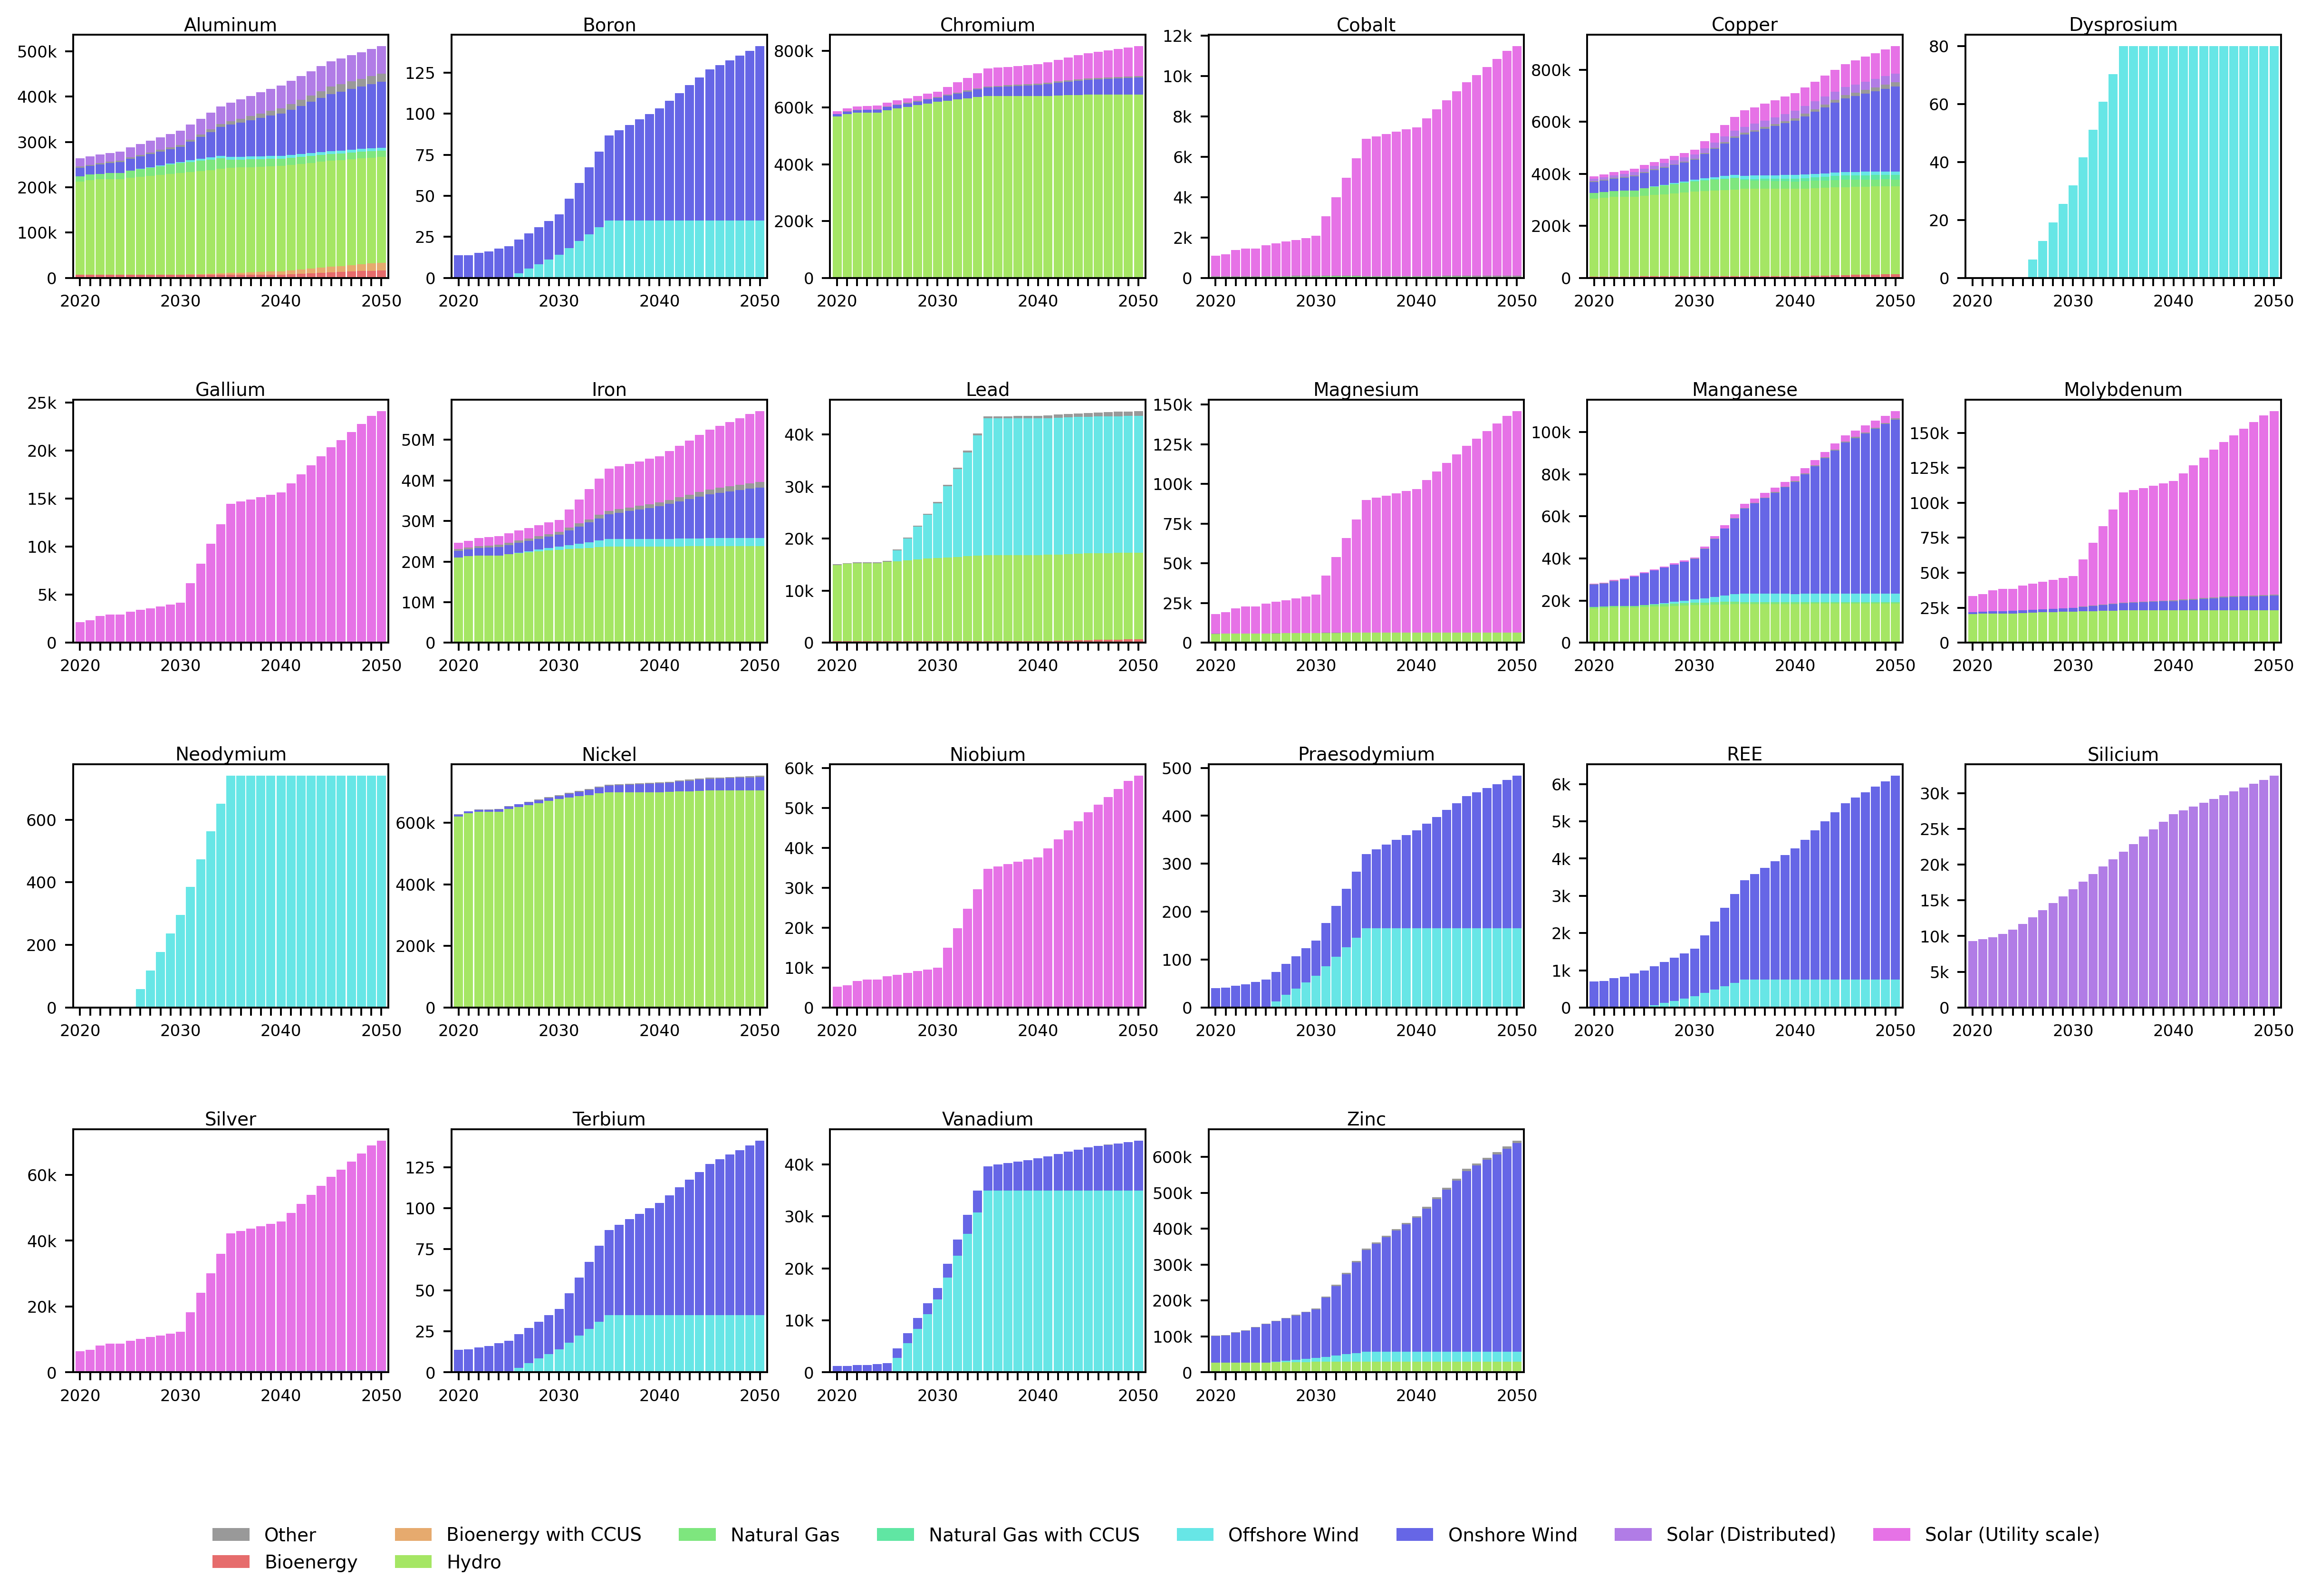

In [20]:
plot_metal_demand_facets(metal_demand_nrj_nz, savepath=r'results/NRJ/metal_demand_nrj_nz_facets')

✅ Figure saved to results/NRJ/metal_demand_nrj_stackplots.png and .svg


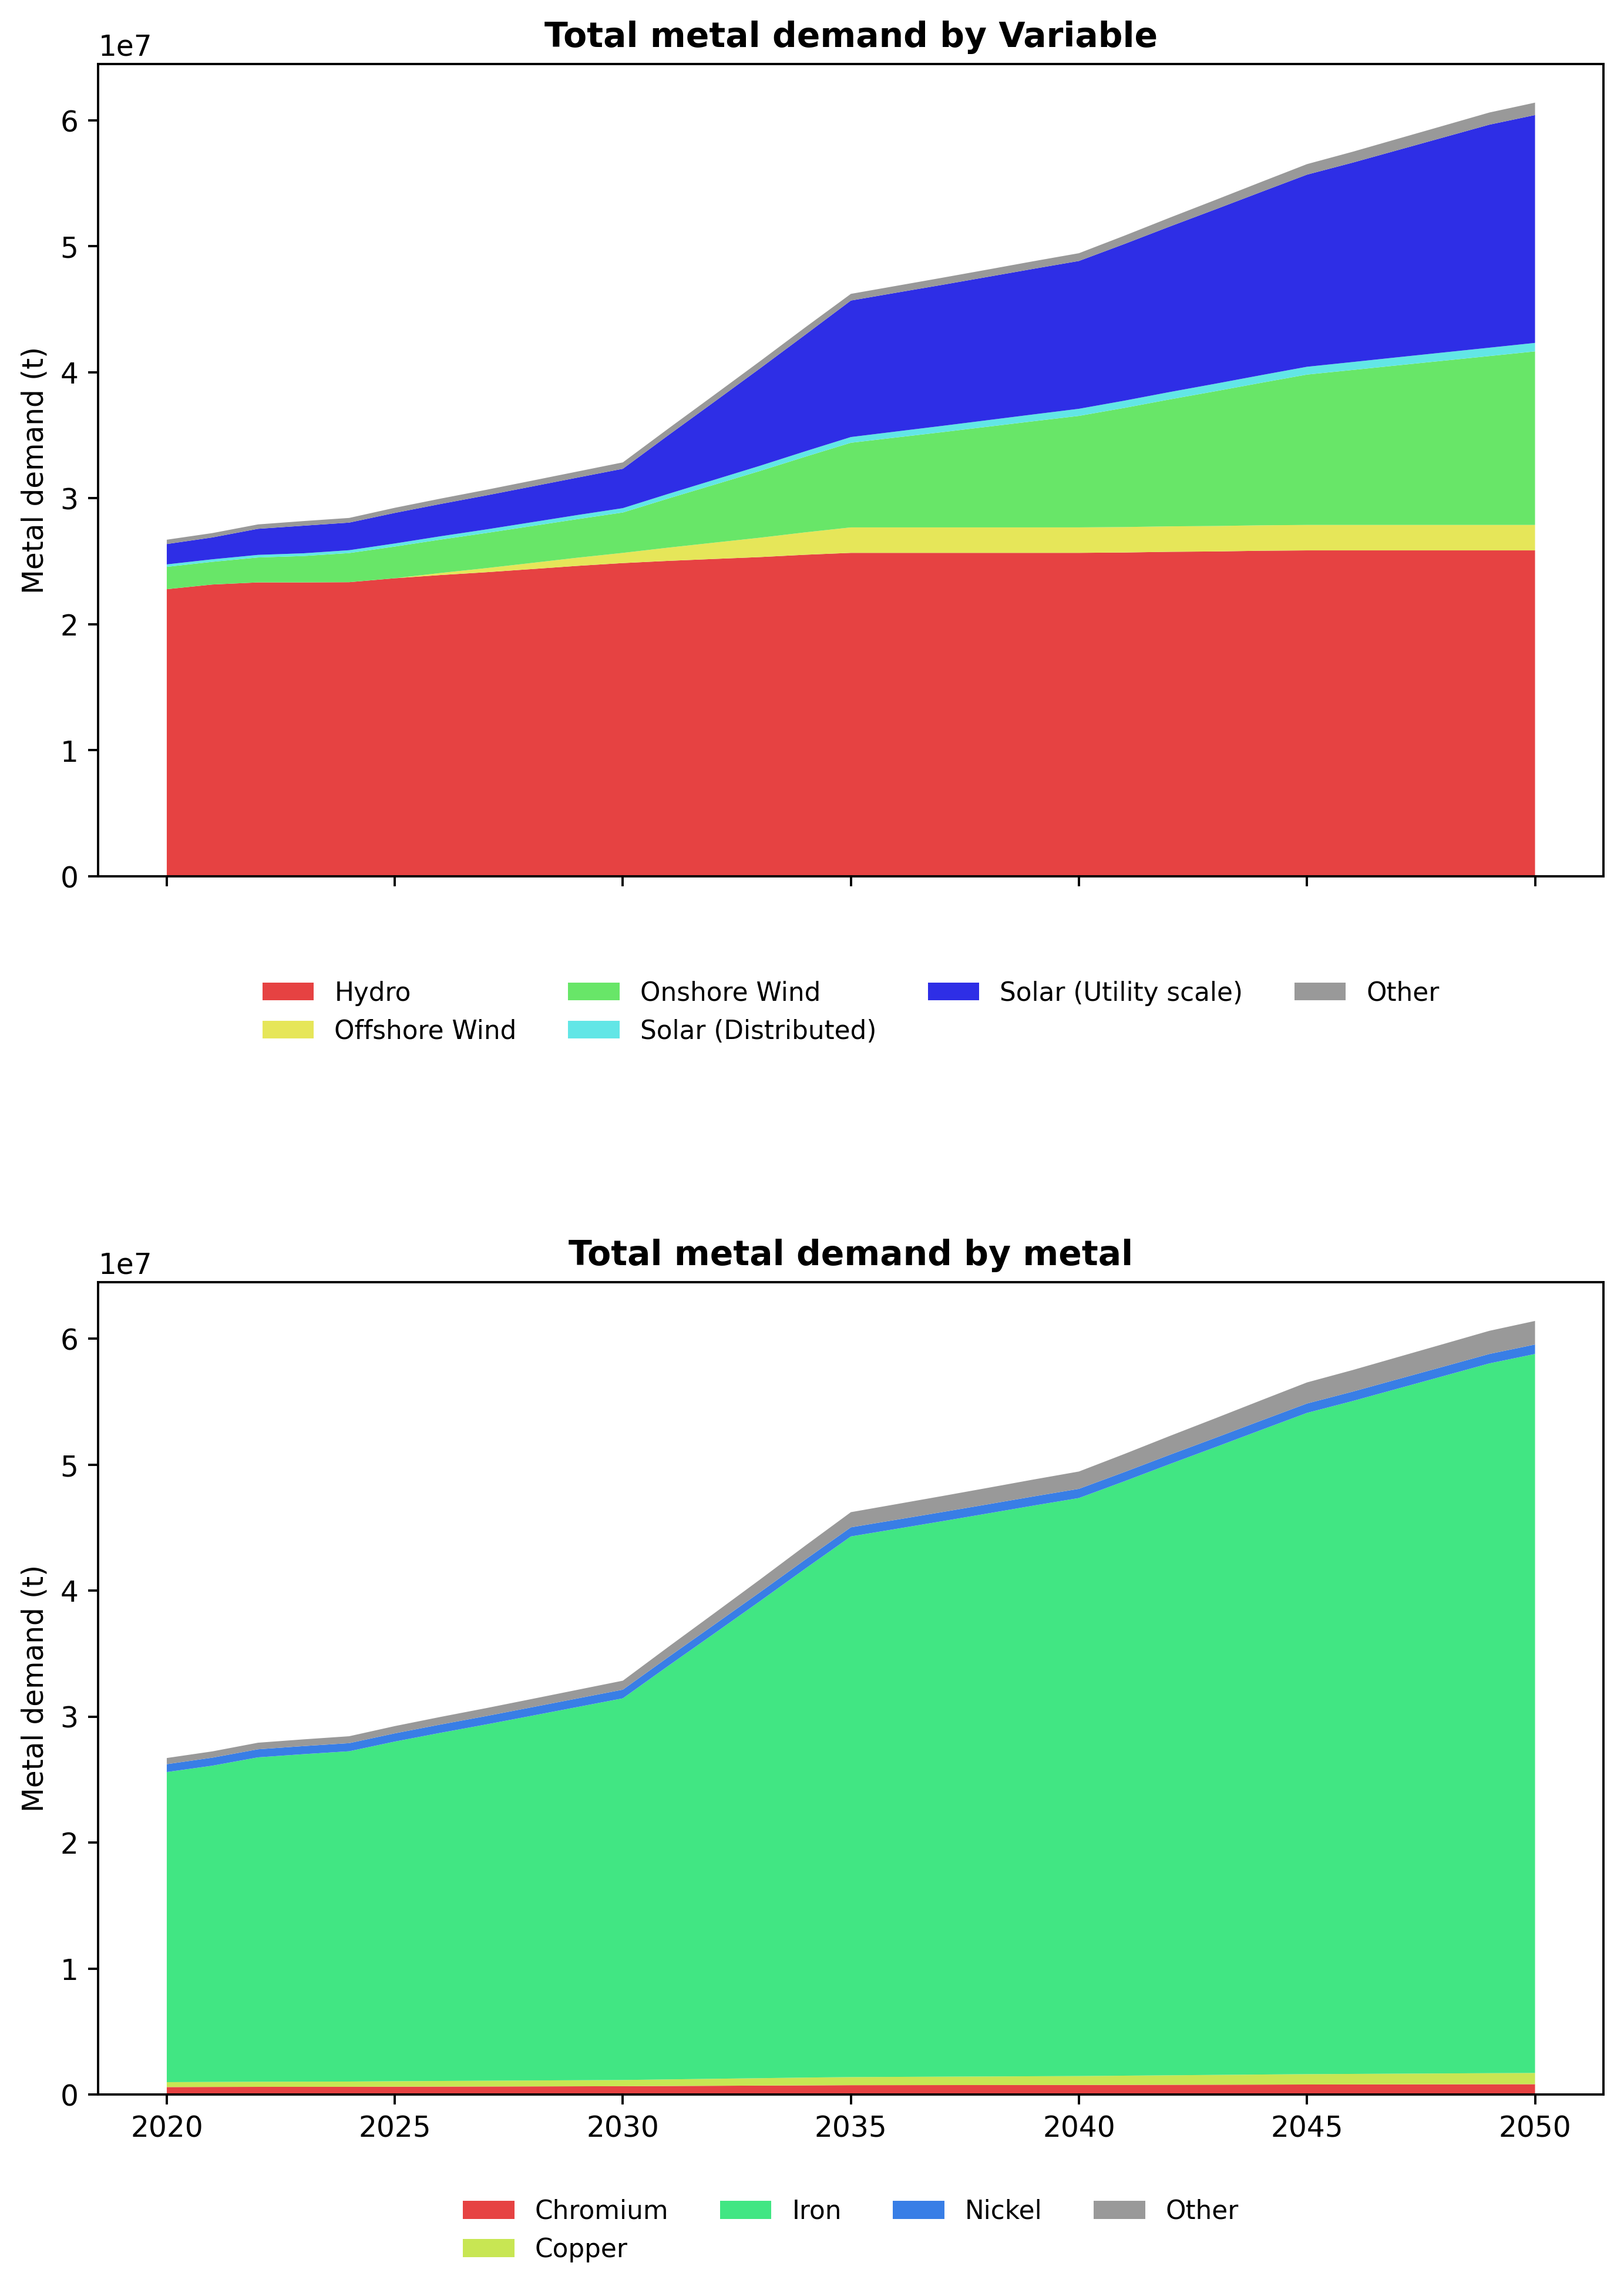

In [21]:
plot_metal_demand_stackplots(metal_demand_nrj_nz, savepath=r'results/NRJ/metal_demand_nrj_stackplots')

# EVs - Battery

## Import data

In [22]:
# EV sales data in Canada from IEA
ev_df = pd.read_excel(r'data/data.xlsx', sheet_name='EVs_CAN')

In [23]:
ev_df = ev_df[
    (ev_df['Parameter'] == 'EV sales') &
    (ev_df['Year'] == 2024)
]

In [24]:
ev_df

,Country,Parameter,Mode,Powertrain,Year,Unit,Value,Mass_vehicule
3,Canada,EV sales,2 and 3 wheelers,BEV,2024,Vehicles,170.0,0.098086
22,Canada,EV sales,Buses,BEV,2024,Vehicles,210.0,5.675237
29,Canada,EV sales,Cars,BEV,2024,Vehicles,190000.0,1.000000
48,Canada,EV sales,Trucks,BEV,2024,Vehicles,2000.0,3.689278
51,Canada,EV sales,Vans,BEV,2024,Vehicles,11000.0,1.957751
66,Canada,EV sales,Buses,FCEV,2024,Vehicles,13.0,5.675237
101,Canada,EV sales,Cars,FCEV,2024,Vehicles,20.0,1.000000
105,Canada,EV sales,Trucks,FCEV,2024,Vehicles,6.0,3.689278
123,Canada,EV sales,Cars,PHEV,2024,Vehicles,62000.0,1.000000
130,Canada,EV sales,Vans,PHEV,2024,Vehicles,6400.0,1.957751


In [25]:
# End use demand for transport sector in PJ from CER scenarios
transport_demand_ef = pd.read_excel(r'data/data.xlsx', sheet_name='END_USE_TRANSPORT')

In [26]:
# Filter for Year 2024 and above, variable = electricity and region = Canada
transport_demand_elec_ef = transport_demand_ef[
    (transport_demand_ef['Region'] == 'Canada') &
    (transport_demand_ef['Year'] >= 2024) &
    (transport_demand_ef['Variable'] == 'Electricity')
]

In [27]:
transport_demand_elec_ef

,Scenario,Region,Variable,Year,Value,Sector,Unit
1224,Current Measures,Canada,Electricity,2024,11.5558,Transportation,PJ
1235,Current Measures,Canada,Electricity,2025,16.5362,Transportation,PJ
1246,Current Measures,Canada,Electricity,2026,22.2906,Transportation,PJ
1257,Current Measures,Canada,Electricity,2027,28.3160,Transportation,PJ
1268,Current Measures,Canada,Electricity,2028,34.8046,Transportation,PJ
...,...,...,...,...,...,...,...
18336,Global Net-zero,Canada,Electricity,2046,687.7432,Transportation,PJ
18477,Global Net-zero,Canada,Electricity,2047,709.8365,Transportation,PJ
18618,Global Net-zero,Canada,Electricity,2048,731.0948,Transportation,PJ
18759,Global Net-zero,Canada,Electricity,2049,751.4916,Transportation,PJ


## Compute future EV sales based on growth factors (based on 2024 values)

In [28]:
from core.demand_calculations import compute_ev_growth, project_ev_sales

In [29]:
ev_growth_df = compute_ev_growth(transport_demand_elec_ef)
projected_ev_sales_df = project_ev_sales(ev_df, ev_growth_df)

In [30]:
projected_ev_sales_df.drop(columns=['Parameter', 'Unit'], inplace=True)
projected_ev_sales_df.rename(columns={'Value': 'EV_sales'}, inplace=True)

In [31]:
projected_ev_sales_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures
...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero


## Estimate battery capacity

In [32]:
bat_cap_df = pd.read_excel(r'data/data.xlsx', sheet_name='BATTERY_CAP')

In [33]:
bat_cap_df

,Mode,Powertrain,Unit,Battery_cap,Value_min,Value_max,Comment
0,2 and 3 wheelers,BEV,kWh,3.00,1.5,4,NaN
1,Buses,BEV,kWh,300.00,250.0,350,NaN
2,Cars,BEV,kWh,65.00,55.0,75,NaN
3,Trucks,BEV,kWh,350.00,200.0,600,NaN
4,Vans,BEV,kWh,75.00,70.0,80,NaN
5,Buses,FCEV,kWh,35.00,30.0,40,NaN
6,Cars,FCEV,kWh,1.75,1.5,2,NaN
7,Trucks,FCEV,kWh,350.00,200.0,600,NaN
8,Cars,PHEV,kWh,15.00,12.0,18,NaN
9,Vans,PHEV,kWh,21.80,20.0,30,NaN


In [34]:
ev_installed_battery_cap_df = projected_ev_sales_df.merge(bat_cap_df[['Mode', 'Powertrain', 'Battery_cap']], how='left', on=['Mode', 'Powertrain'])
#ev_installed_battery_cap_df.rename(columns={'Value': 'EV_sales'}, inplace=True)

In [35]:
ev_installed_battery_cap_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures,3.00
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures,300.00
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures,65.00
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures,350.00
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures,75.00
...,...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero,35.00
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero,1.75
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero,350.00
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero,15.00


In [36]:
ev_installed_battery_cap_df['Installed_battery_cap'] = ev_installed_battery_cap_df['Battery_cap'] * ev_installed_battery_cap_df['EV_sales']

In [37]:
ev_installed_battery_cap_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap,Installed_battery_cap
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures,3.00,5.100000e+02
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures,300.00,6.300000e+04
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures,65.00,1.235000e+07
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures,350.00,7.000000e+05
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures,75.00,8.250000e+05
...,...,...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero,35.00,2.068930e+04
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero,1.75,1.591485e+03
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero,350.00,9.548909e+04
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero,15.00,4.228802e+07


## Add chemistry mix scenario

In [38]:
chemistry_mix_df = pd.read_excel(r'data/data.xlsx', sheet_name='BATTERY_MIX')

In [39]:
ev_installed_battery_cap_df = apply_chemistry_mix(ev_installed_battery_cap_df, chemistry_mix_df)

In [40]:
ev_installed_battery_cap_df

,Country,Mode,Battery_type,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap,Installed_battery_cap
0,Canada,2 and 3 wheelers,All,BEV,2024,170.000000,0.098086,Current Measures,3.0,5.100000e+02
1,Canada,Buses,All,BEV,2024,210.000000,5.675237,Current Measures,300.0,6.300000e+04
2,Canada,Cars,All,BEV,2024,190000.000000,1.000000,Current Measures,65.0,1.235000e+07
3,Canada,Trucks,All,BEV,2024,2000.000000,3.689278,Current Measures,350.0,7.000000e+05
4,Canada,Vans,All,BEV,2024,11000.000000,1.957751,Current Measures,75.0,8.250000e+05
...,...,...,...,...,...,...,...,...,...,...
3640,Canada,Vans,LMFP,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,2.765805e+06
3641,Canada,Vans,LMO,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,0.000000e+00
3642,Canada,Vans,NCA,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,0.000000e+00
3643,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,0.000000e+00


In [41]:
evs_battery_mi_mapping = { # From Battery_type to Technology, Sub-technology
    "LFP": [("Vehicle battery, LFP", 1.0)],
    "LMFP": [("Vehicle battery, LMFP", 1.0)],
    "LMO": [("Vehicle battery, LMO", 1.0)],
    "NCA": [("Vehicle battery, NCA", 1.0)],
    "NMC": [("Vehicle battery, NMC", 1.0)],
    "Na-ion": [("Vehicle battery, Na-ion", 1.0)],
}

In [42]:
material_demand_ev_battery = calculate_metal_demand_ev_battery(ev_installed_battery_cap_df, mi_df, evs_battery_mi_mapping)
material_demand_ev_battery.dropna(subset=["Metal intensity (g/kWh)"], inplace=True)
material_demand_ev_battery.drop(columns=["Battery_cap", "Technology", "Sub-technology"], inplace=True)
material_demand_ev_battery

,Country,Mode,Battery_type,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Installed_battery_cap,Metal,Metal intensity (g/kWh),Metal_demand_t,Fiability_used,Comment
810,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,510.000000,Aluminum,46.400078,0.023664,No comparison,"(battery production, Li-ion, LFP, rechargeable)"
811,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,510.000000,Cobalt,1536.850581,0.783794,Important variability in data,"(battery production, Li-ion, LFP, rechargeable)"
812,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,510.000000,Copper,493.224834,0.251545,Variability in data,(Gr-LFP)
813,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,510.000000,Lithium,128.513916,0.065542,Small variability in data,mean of Small variability in data
814,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,510.000000,Manganese,1492.450788,0.761150,Variability in data,"(battery production, Li-ion, LFP, rechargeable)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12631,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,0.000000,Lithium,373.861871,0.000000,Variability in data,mean of Variability in data
12632,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,0.000000,Manganese,158.536576,0.000000,No comparison,(Gr-NMC)
12633,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,0.000000,Nickel,563.685669,0.000000,No comparison,(Gr-NMC)
12634,Canada,Vans,Na-ion,PHEV,2050,291014.359845,1.957751,Global Net-zero,663708.608351,Manganese,554.878014,368.277315,Variability in data,None


In [43]:
material_demand_ev_battery_nz = material_demand_ev_battery[material_demand_ev_battery['Scenario'] == 'Canada Net-zero']
material_demand_ev_battery_step = material_demand_ev_battery[material_demand_ev_battery['Scenario'] == 'Canada Current Measures']

In [44]:
metal_demand_ev_battery = material_demand_ev_battery[~material_demand_ev_battery['Metal'].isin(non_metals)]
metal_demand_ev_battery_nz = metal_demand_ev_battery[metal_demand_ev_battery['Scenario'] == 'Canada Net-zero']
metal_demand_ev_battery_step = metal_demand_ev_battery[metal_demand_ev_battery['Scenario'] == 'Canada Current Measures']

In [45]:
material_demand_ev_battery.to_csv(r'results/EVs_battery/material_demand_ev.csv', index=False)
metal_demand_ev_battery.to_csv(r'results/EVs_battery/metal_demand_ev.csv', index=False)

## PLots

✅ Saved to results/EVs_battery/metal_demand_ev_facets_by_mode.png / .svg


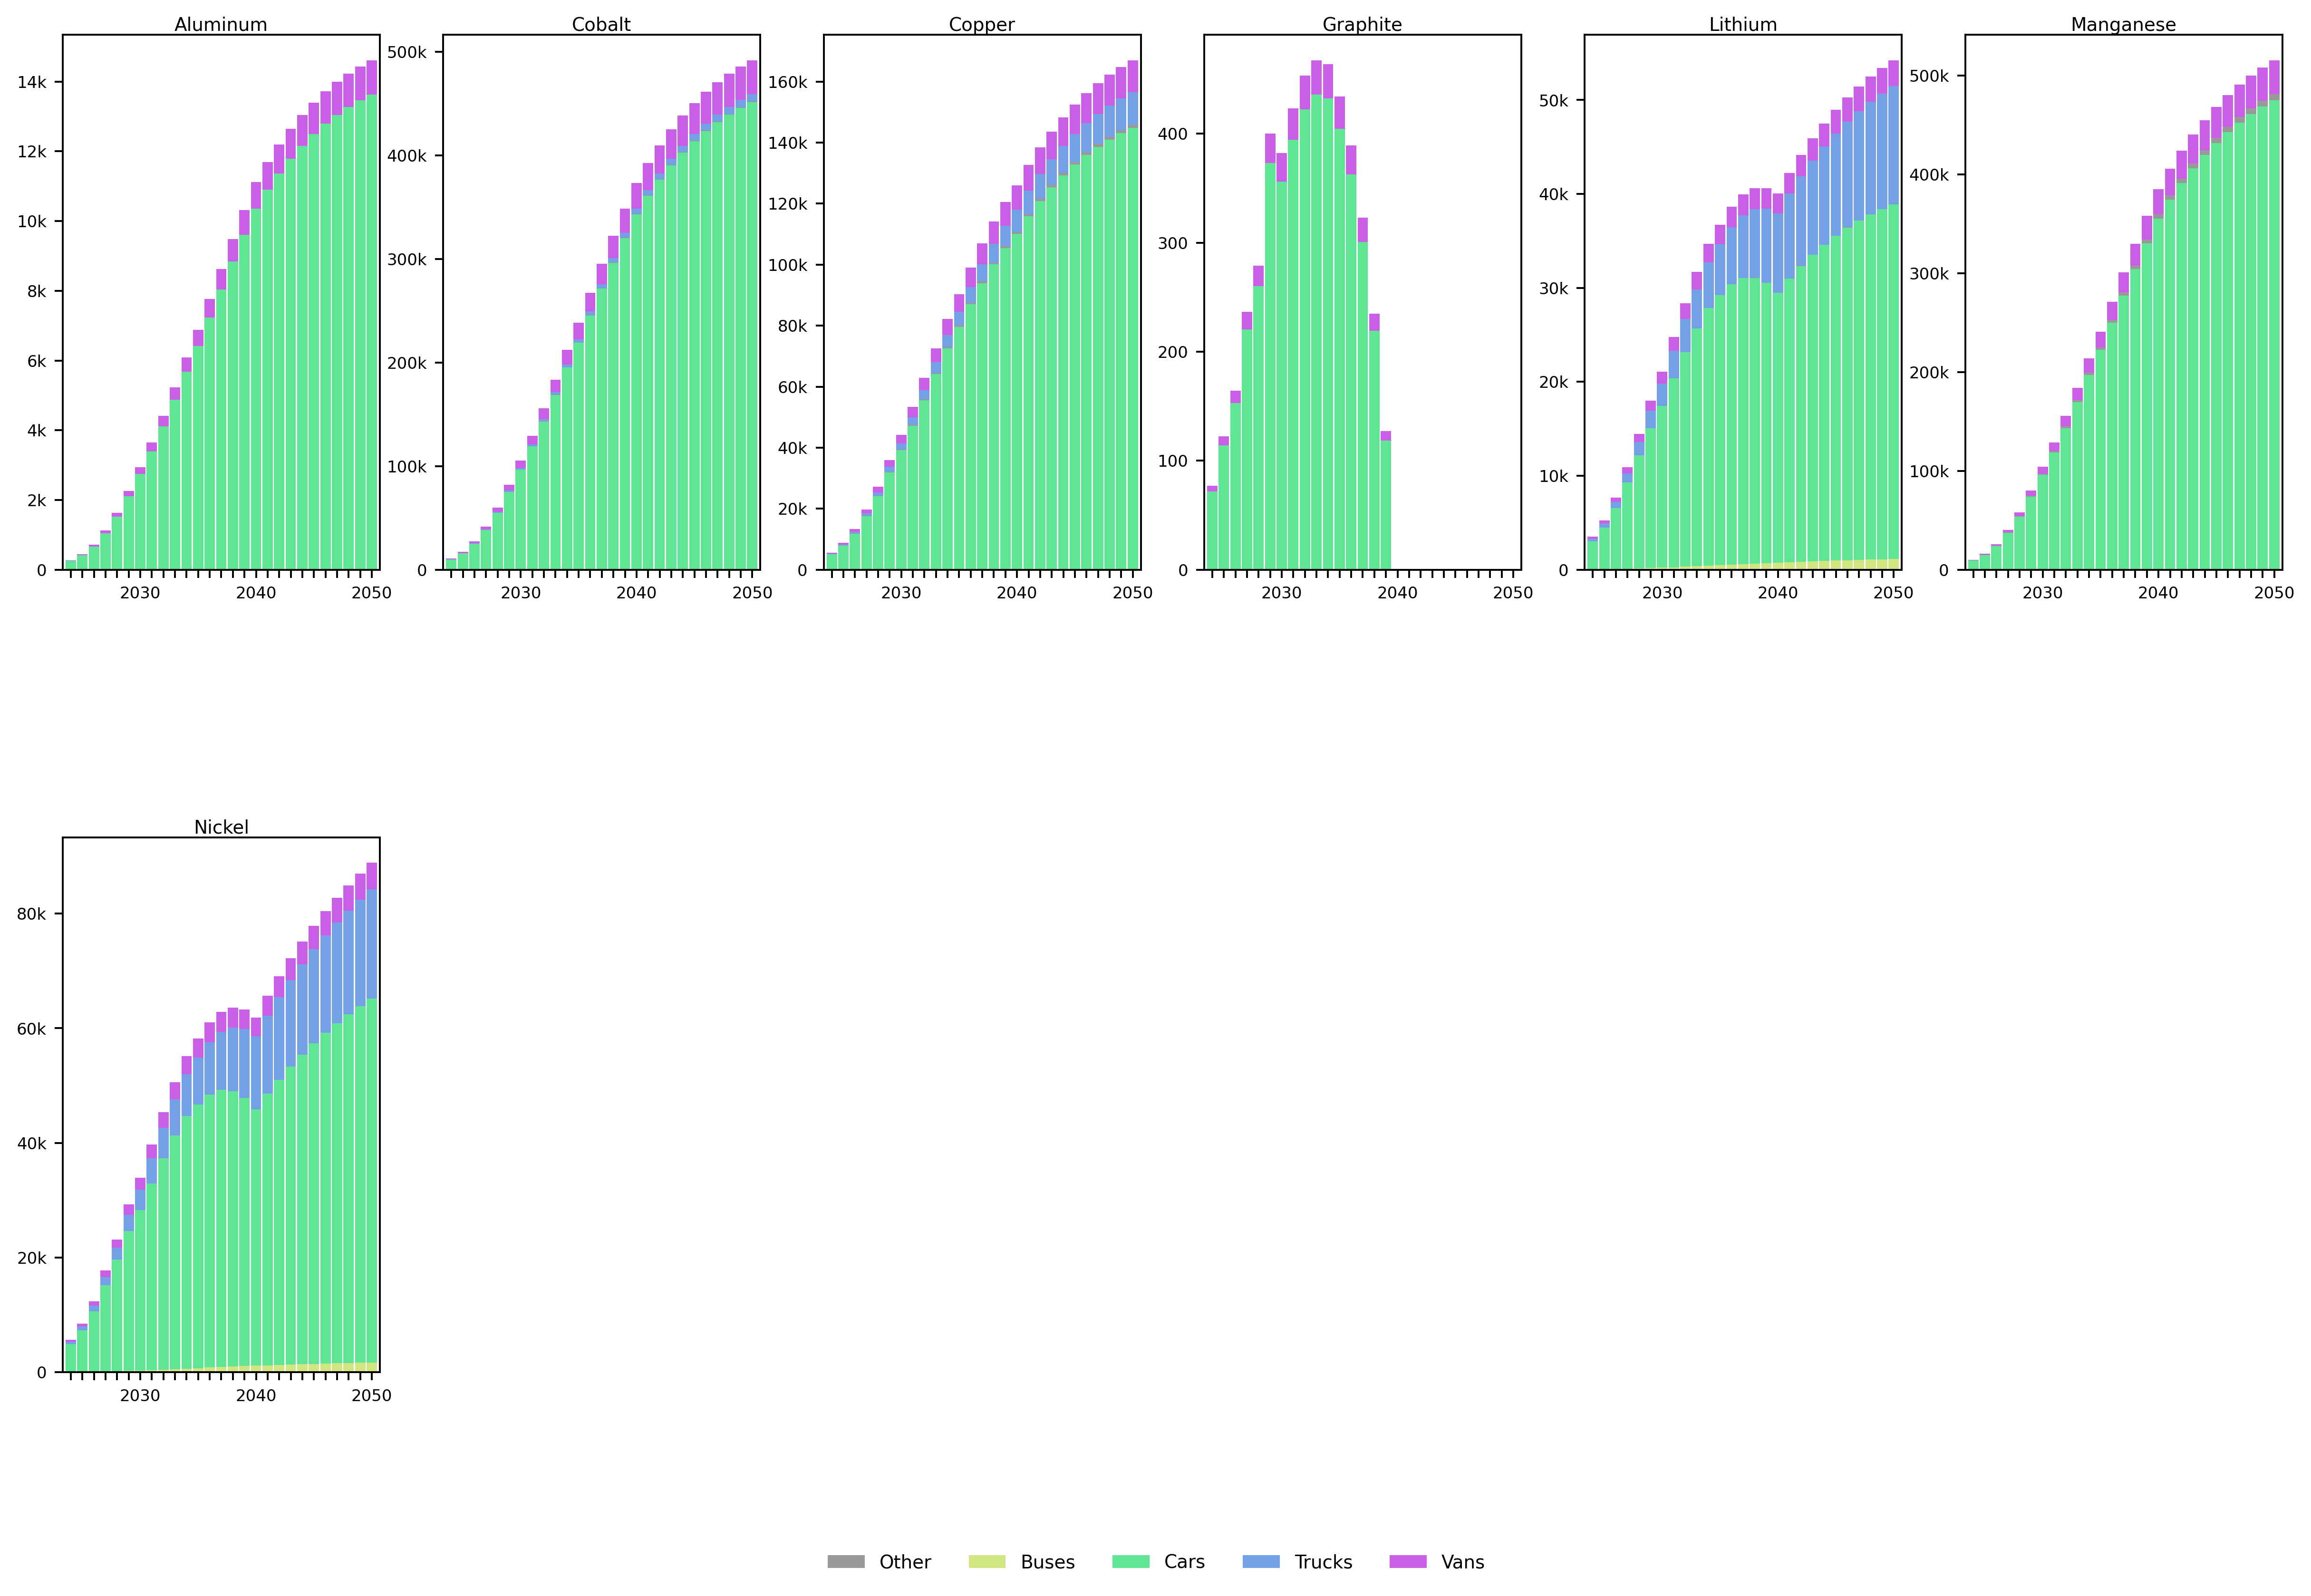

In [46]:
plot_metal_demand_facets(metal_demand_ev_battery_nz, variable_col='Mode', savepath="results/EVs_battery/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_battery/metal_demand_ev_stackplot_by_mode.png and .svg


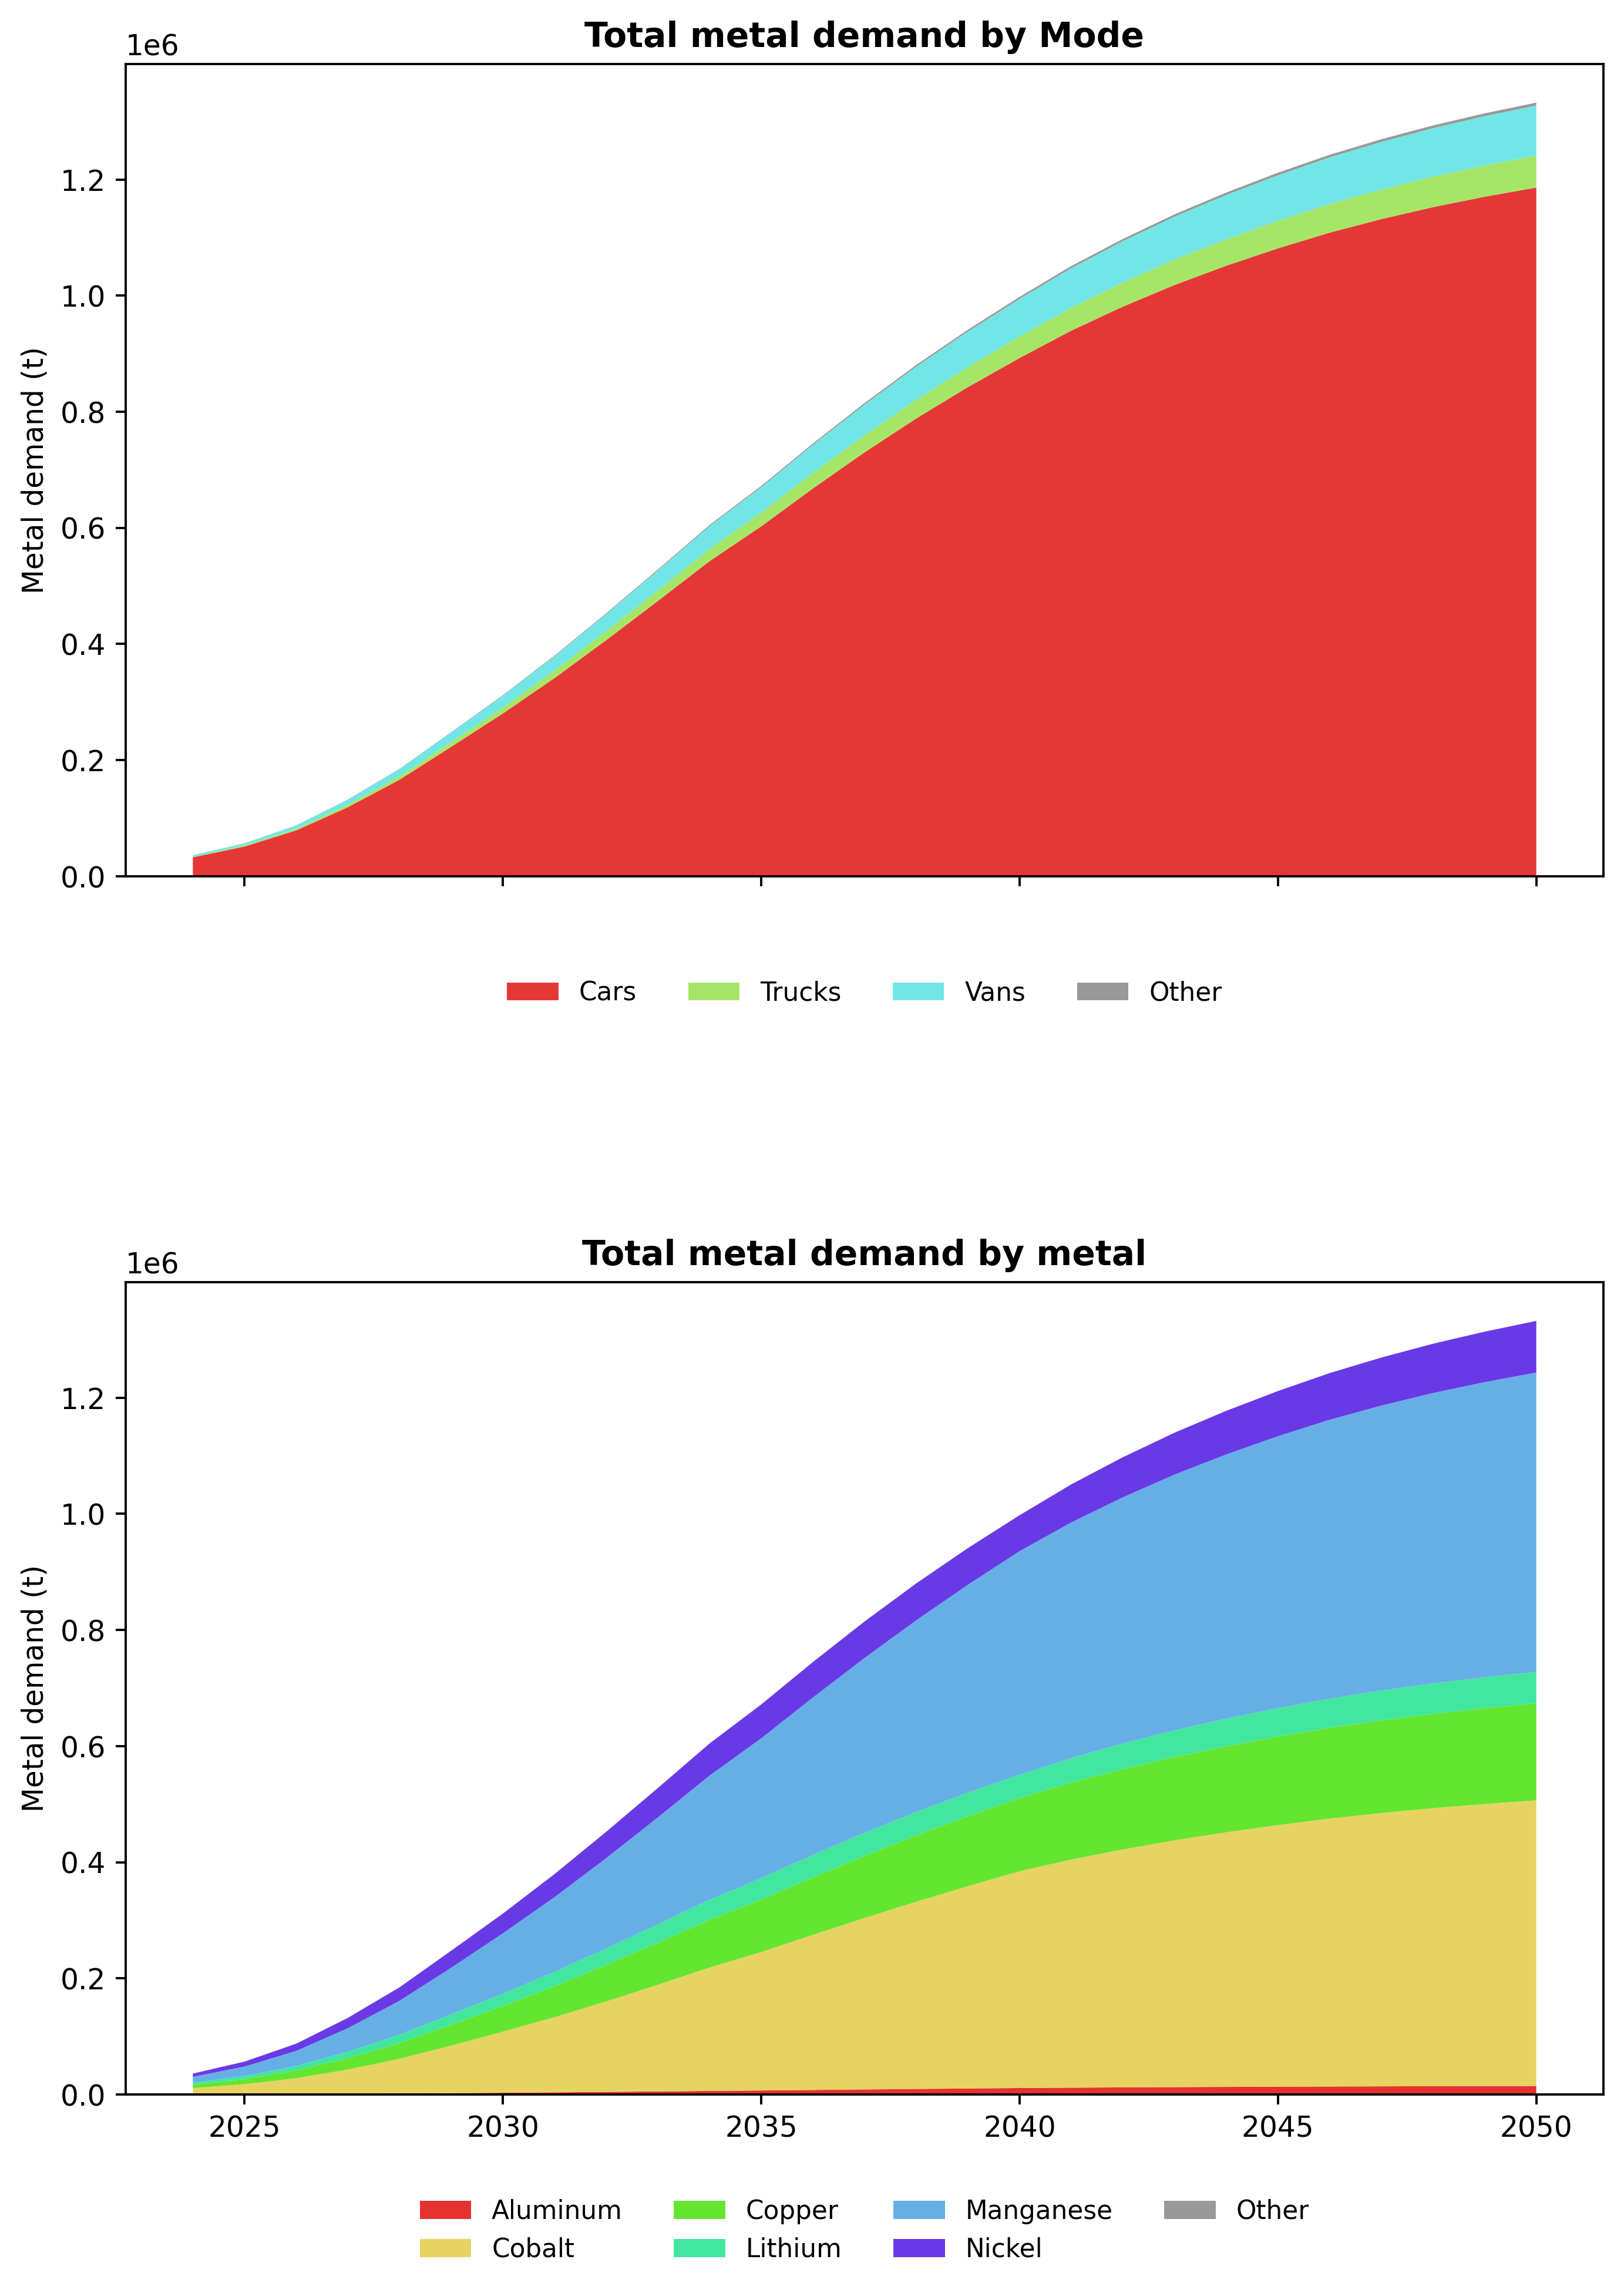

In [47]:
plot_metal_demand_stackplots(metal_demand_ev_battery_nz, variable_col="Mode", savepath="results/EVs_battery/metal_demand_ev_stackplot_by_mode")

# EVs - Vehicle body

## Vehicules en circulation from QC

In [48]:
df_veh_qc = pd.read_csv(r'data/EVs/Vehicule_En_Circulation_2022.csv', index_col=False)

In [49]:
# Define as float
df_veh_qc['ANNEE_MOD'] = pd.to_numeric(df_veh_qc['ANNEE_MOD'], errors='coerce')
df_veh_qc['MASSE_NETTE'] = pd.to_numeric(df_veh_qc['MASSE_NETTE'], errors='coerce')
df_veh_qc = df_veh_qc[df_veh_qc['ANNEE_MOD'] > 2020]
df_veh_qc

,AN,NOSEQ_VEH,CLAS,TYP_VEH_CATEG_USA,MARQ_VEH,MODEL_VEH,ANNEE_MOD,MASSE_NETTE,NB_CYL,CYL_VEH,NB_ESIEU_MAX,COUL_ORIG,TYP_CARBU,REG_ADM,MRC,CG_FIXE
15,2022,2022_0000000016,CAU,AU,AUDI,Q5,2022.0,1798.0,4.0,2000.0,NaN,BLE,E,Laval (13),Laval (65 ),65005.0
18,2022,2022_0000000019,CAU,AU,NISSA,LEAF,2021.0,1746.0,NaN,NaN,NaN,BLA,L,Montérégie (16),Longueuil (58 ),58227.0
21,2022,2022_0000000022,PAU,AU,NISSA,KICKS,2021.0,1204.0,4.0,1607.0,NaN,GRI,E,Montérégie (16),Beauharnois-Salaberry (70 ),70052.0
27,2022,2022_0000000028,PAU,AU,TOYOT,RAV4,2021.0,1635.0,4.0,2509.0,NaN,VER,E,Outaouais (07),Gatineau (81 ),81017.0
30,2022,2022_0000000031,PHM,HM,THOR,TELLA,2022.0,3226.0,6.0,3608.0,NaN,NaN,E,Montérégie (16),Longueuil (58 ),58227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7058561,2022,2022_0007058562,PAU,AU,TOYOT,RAV4,2021.0,1580.0,4.0,2509.0,NaN,BLA,E,Gaspésie–Îles-de-la-Madeleine (11),Com.maritime ÎlesDeLaMadeleine (01 ),1023.0
7058562,2022,2022_0007058563,PAU,AU,INFIN,Q50,2021.0,1760.0,6.0,3001.0,NaN,NaN,E,Laval (13),Laval (65 ),65005.0
7058587,2022,2022_0007058588,PAU,AU,BMW,X5,2021.0,2561.0,6.0,3001.0,NaN,NOI,W,Montréal (06),Montréal (66 ),66023.0
7058592,2022,2022_0007058593,CAU,AU,SUBAR,ASCEN,2022.0,2005.0,4.0,2394.0,NaN,BLA,E,Montréal (06),Montréal (66 ),66112.0


In [50]:
from utils.constants import CLAS, TYP_CARBU

In [51]:
df_veh_qc['CLAS'] = df_veh_qc['CLAS'].map(CLAS)
df_veh_qc['TYP_CARBU'] = df_veh_qc['TYP_CARBU'].map(TYP_CARBU)

In [52]:
df_veh_qc_ev = df_veh_qc[df_veh_qc['TYP_CARBU'] == 'Électricité']
col_to_keep = ['AN', 'CLAS', 'MARQ_VEH', 'MODEL_VEH', 'ANNEE_MOD', 'MASSE_NETTE', 'TYP_CARBU']
df_veh_qc_ev = df_veh_qc_ev[col_to_keep]

C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\fasc_metal_sustainability\utils\visualisations.py:285: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col_clas, y=col_mass, data=df, showfliers=False, palette="Set3")


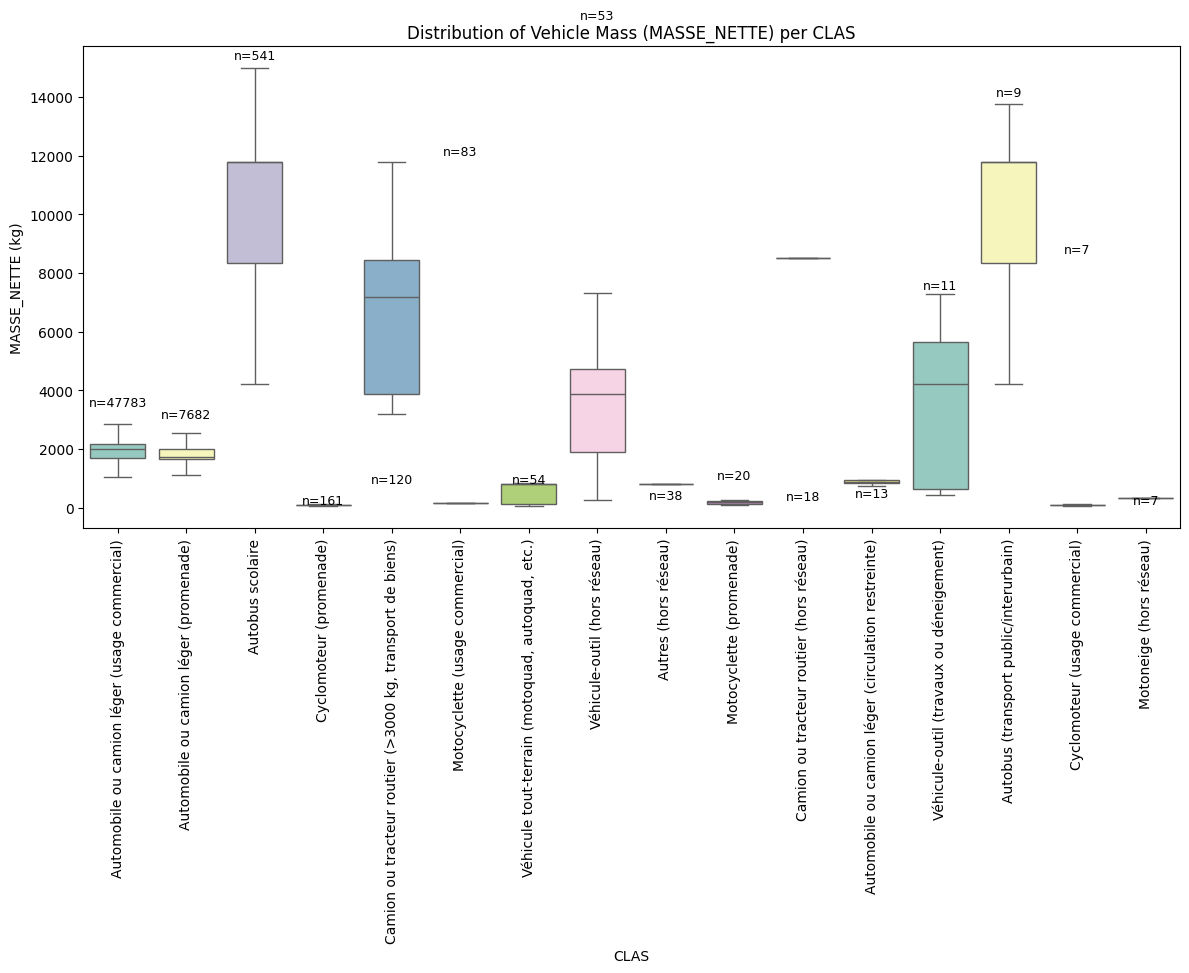

In [53]:
df_veh_qc_ev_mass = plot_masse_stats_per_clas(df_veh_qc_ev)

In [54]:
df_veh_qc_ev_mass

,Mean,Median,Min,Max,Count,Q25,Q75
CLAS,,,,,,,
Autobus scolaire,10332.576710,11793.0,2313.0,14982.0,541,8350.0,11793.0
Autobus (transport public/interurbain),10056.333333,11793.0,4200.0,13753.0,9,8350.0,11793.0
Camion ou tracteur routier (hors réseau),8513.000000,8513.0,8513.0,8513.0,7,8513.0,8513.0
"Camion ou tracteur routier (>3000 kg, transport de biens)",6716.855422,7180.0,3201.0,11793.0,83,3879.0,8430.0
Véhicule-outil (hors réseau),3928.660377,3870.0,259.0,16329.0,53,1902.0,4720.0
Véhicule-outil (travaux ou déneigement),3564.363636,4210.0,414.0,7300.0,11,628.5,5650.0
Automobile ou camion léger (usage commercial),2014.812549,2003.0,736.0,2992.0,7682,1707.0,2173.0
Automobile ou camion léger (promenade),1820.642195,1740.0,1000.0,3402.0,47783,1640.0,2003.0
Automobile ou camion léger (circulation restreinte),862.750000,863.0,748.0,940.0,20,823.0,940.0


## Estimate material demand

In [55]:
evs_body_mi_mapping = { # From Powertrain to Technology, Sub-technology
    "BEV": [("Vehicle body, BEV", 1.0)],
    "FCEV": [("Vehicle body, ICEV", 1.0)],
    "PHEV": [("Vehicle body, PHEV", 1.0)]
}

In [56]:
material_demand_ev_body = calculate_metal_demand_ev_body(projected_ev_sales_df, mi_df, mapping_dict=evs_body_mi_mapping, main_var="EV_sales")

In [57]:
material_demand_ev_body

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Technology,Sub-technology,Metal,Metal intensity (kg/vehicle),Metal_demand_t,Fiability_used,Comment
0,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Aluminum,127302.00,2.122706e+03,No comparison,None
1,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Chromium,11850.00,1.975936e+02,No comparison,None
2,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Iron,902171.34,1.504332e+04,No comparison,None
3,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Lead,310.00,5.169116e+00,No comparison,None
4,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Zinc,100.00,1.667457e+00,No comparison,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3802,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Aluminum,110658.00,6.304558e+07,No comparison,None
3803,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Chromium,12789.00,7.286323e+06,No comparison,None
3804,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Iron,902171.34,5.139973e+08,No comparison,None
3805,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Lead,320.00,1.823147e+05,No comparison,None


In [58]:
material_demand_ev_body_nz = material_demand_ev_body[material_demand_ev_body['Scenario'] == 'Canada Net-zero']
material_demand_ev_body_step = material_demand_ev_body[material_demand_ev_body['Scenario'] == 'Canada Current Measures']

In [59]:
metal_demand_ev_body = material_demand_ev_body[~material_demand_ev_body['Metal'].isin(non_metals)]
metal_demand_ev_body_nz = metal_demand_ev_body[metal_demand_ev_body['Scenario'] == 'Canada Net-zero']
metal_demand_ev_body_step = metal_demand_ev_body[metal_demand_ev_body['Scenario'] == 'Canada Current Measures']

In [60]:
material_demand_ev_body.to_csv(r'results/EVs_body/material_demand_ev_body.csv', index=False)
metal_demand_ev_body.to_csv(r'results/EVs_body/metal_demand_ev_body.csv', index=False)

In [61]:
metal_demand_ev_body_nz

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Technology,Sub-technology,Metal,Metal intensity (kg/vehicle),Metal_demand_t,Fiability_used,Comment
1269,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Aluminum,127302.00,2.122706e+03,No comparison,None
1270,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Chromium,11850.00,1.975936e+02,No comparison,None
1271,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Iron,902171.34,1.504332e+04,No comparison,None
1272,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Lead,310.00,5.169116e+00,No comparison,None
1273,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Zinc,100.00,1.667457e+00,No comparison,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2533,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Aluminum,110658.00,6.671809e+07,No comparison,None
2534,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Chromium,12789.00,7.710763e+06,No comparison,None
2535,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Iron,902171.34,5.439385e+08,No comparison,None
2536,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Lead,320.00,1.929349e+05,No comparison,None


## Plots

✅ Saved to results/EVs_body/metal_demand_ev_facets_by_mode.png / .svg


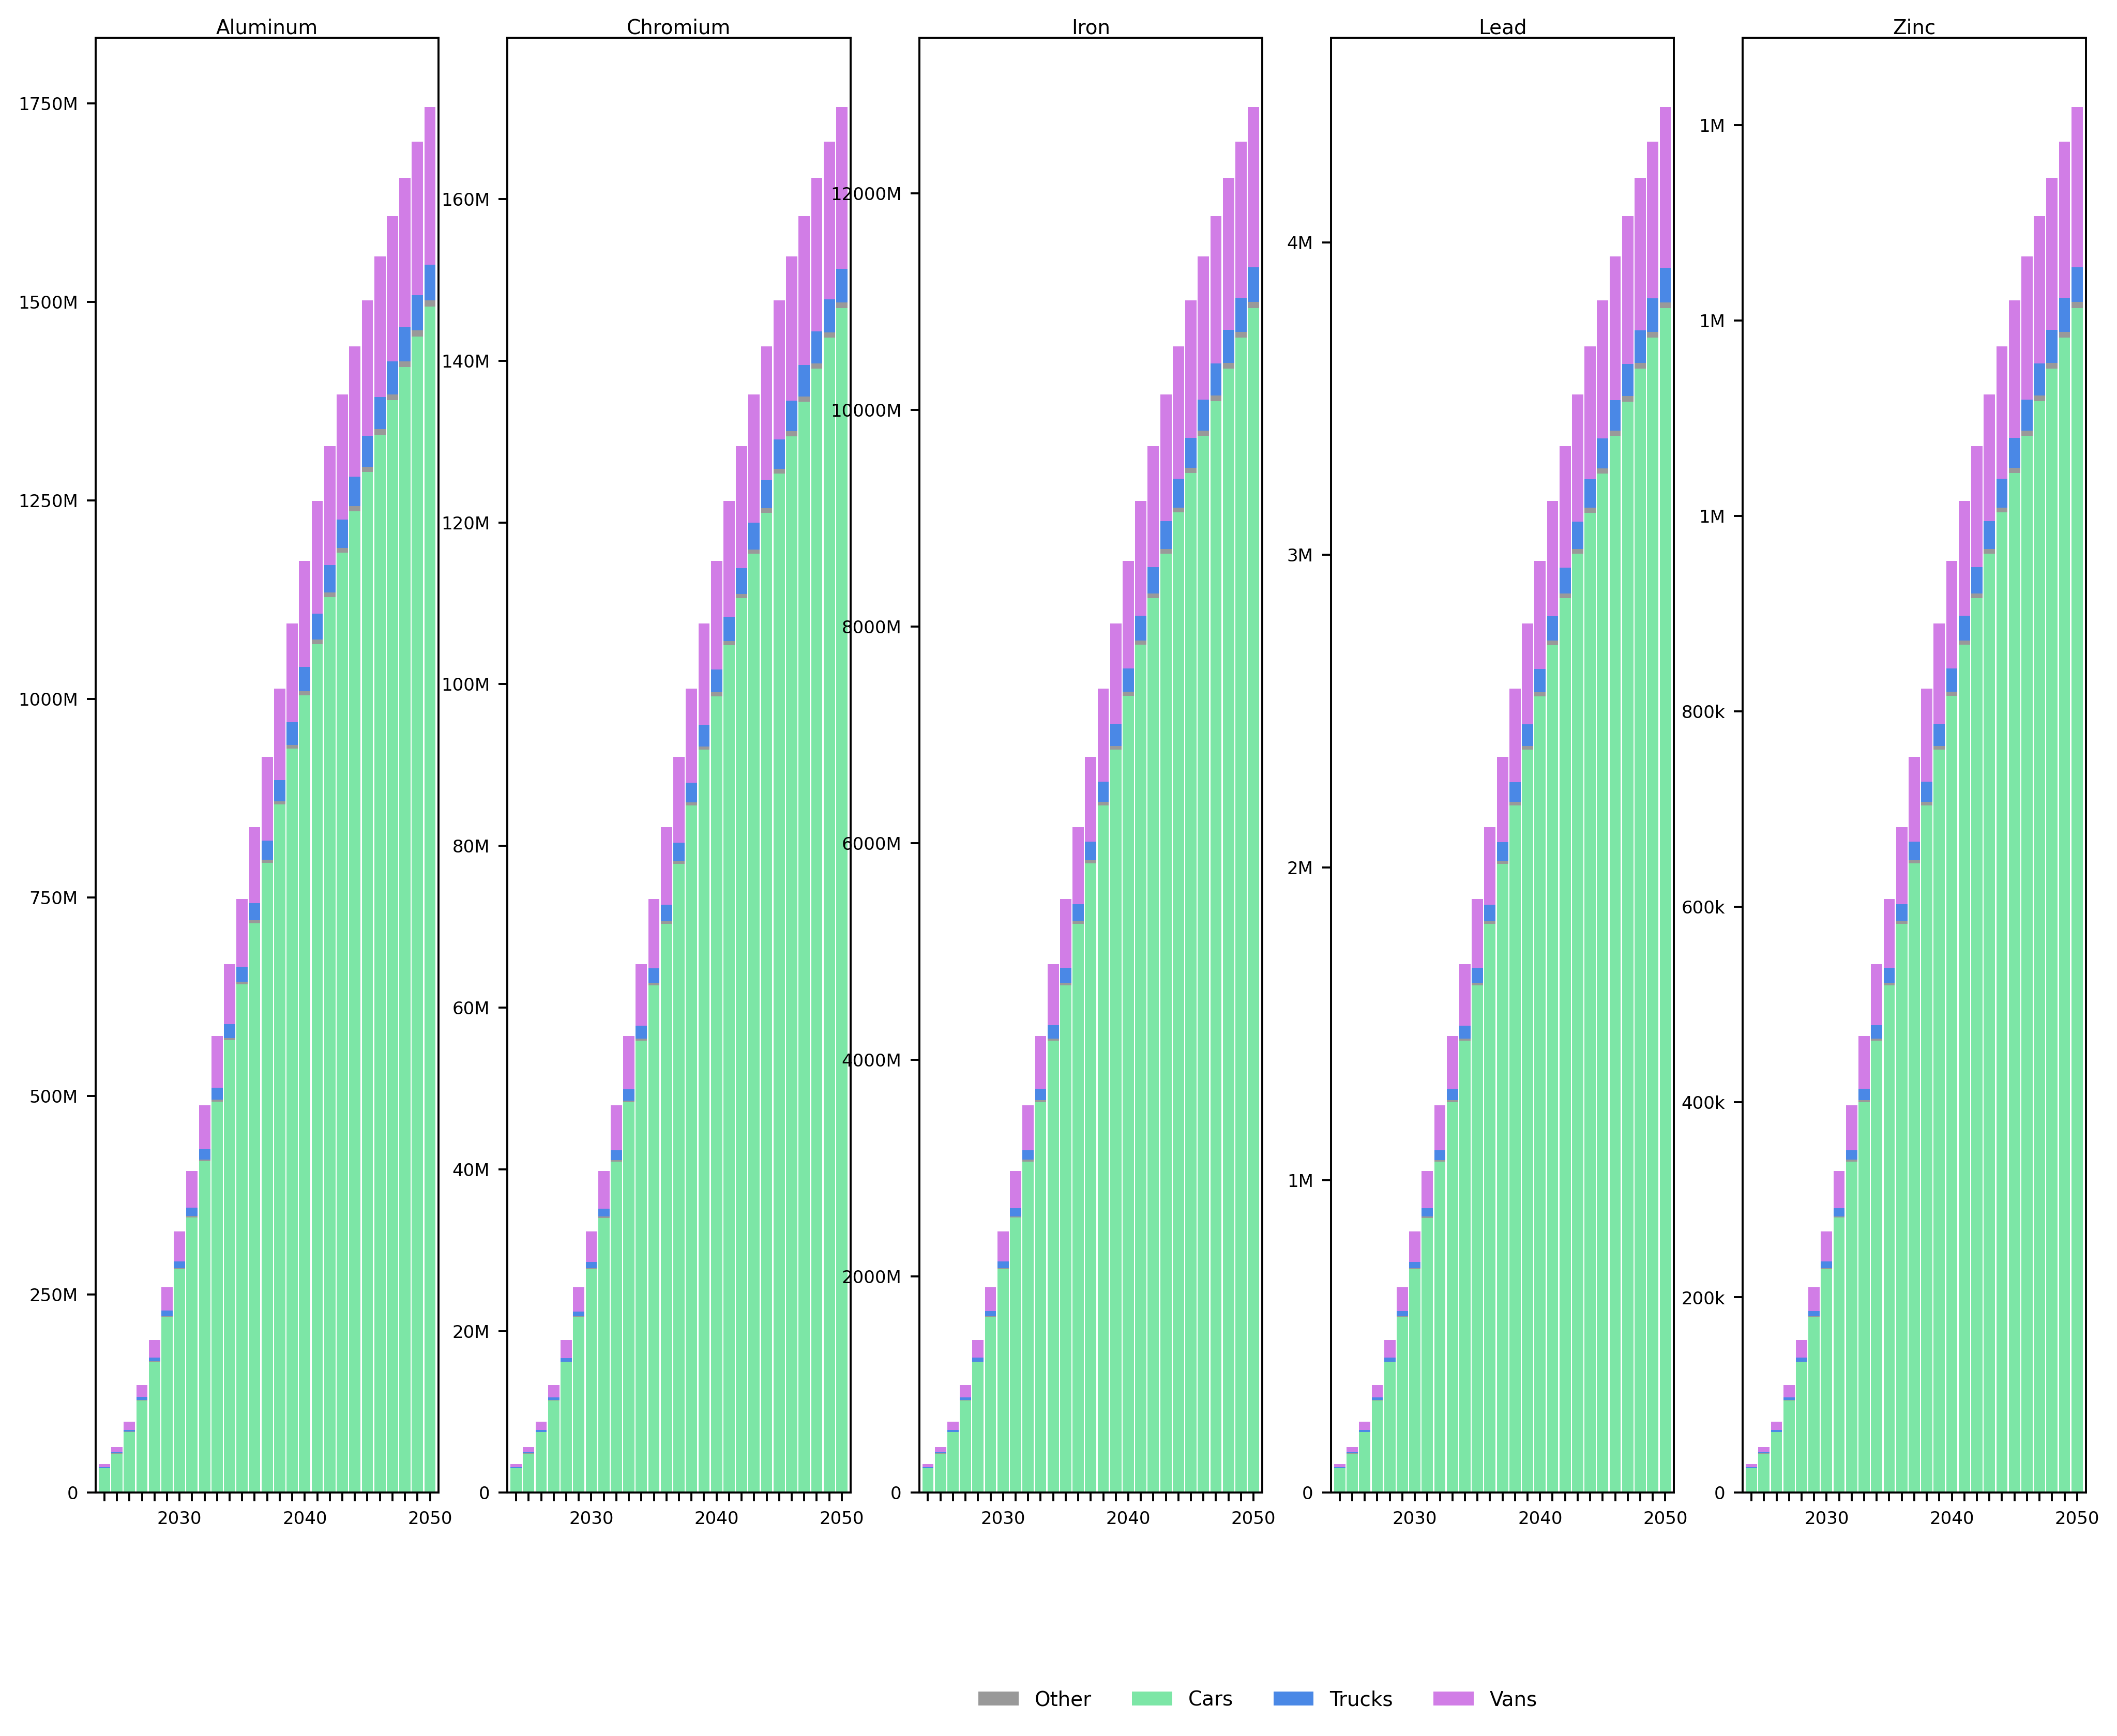

In [62]:
plot_metal_demand_facets(metal_demand_ev_body_nz, variable_col='Mode', savepath="results/EVs_body/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_body/metal_demand_ev_stackplot_by_mode.png and .svg


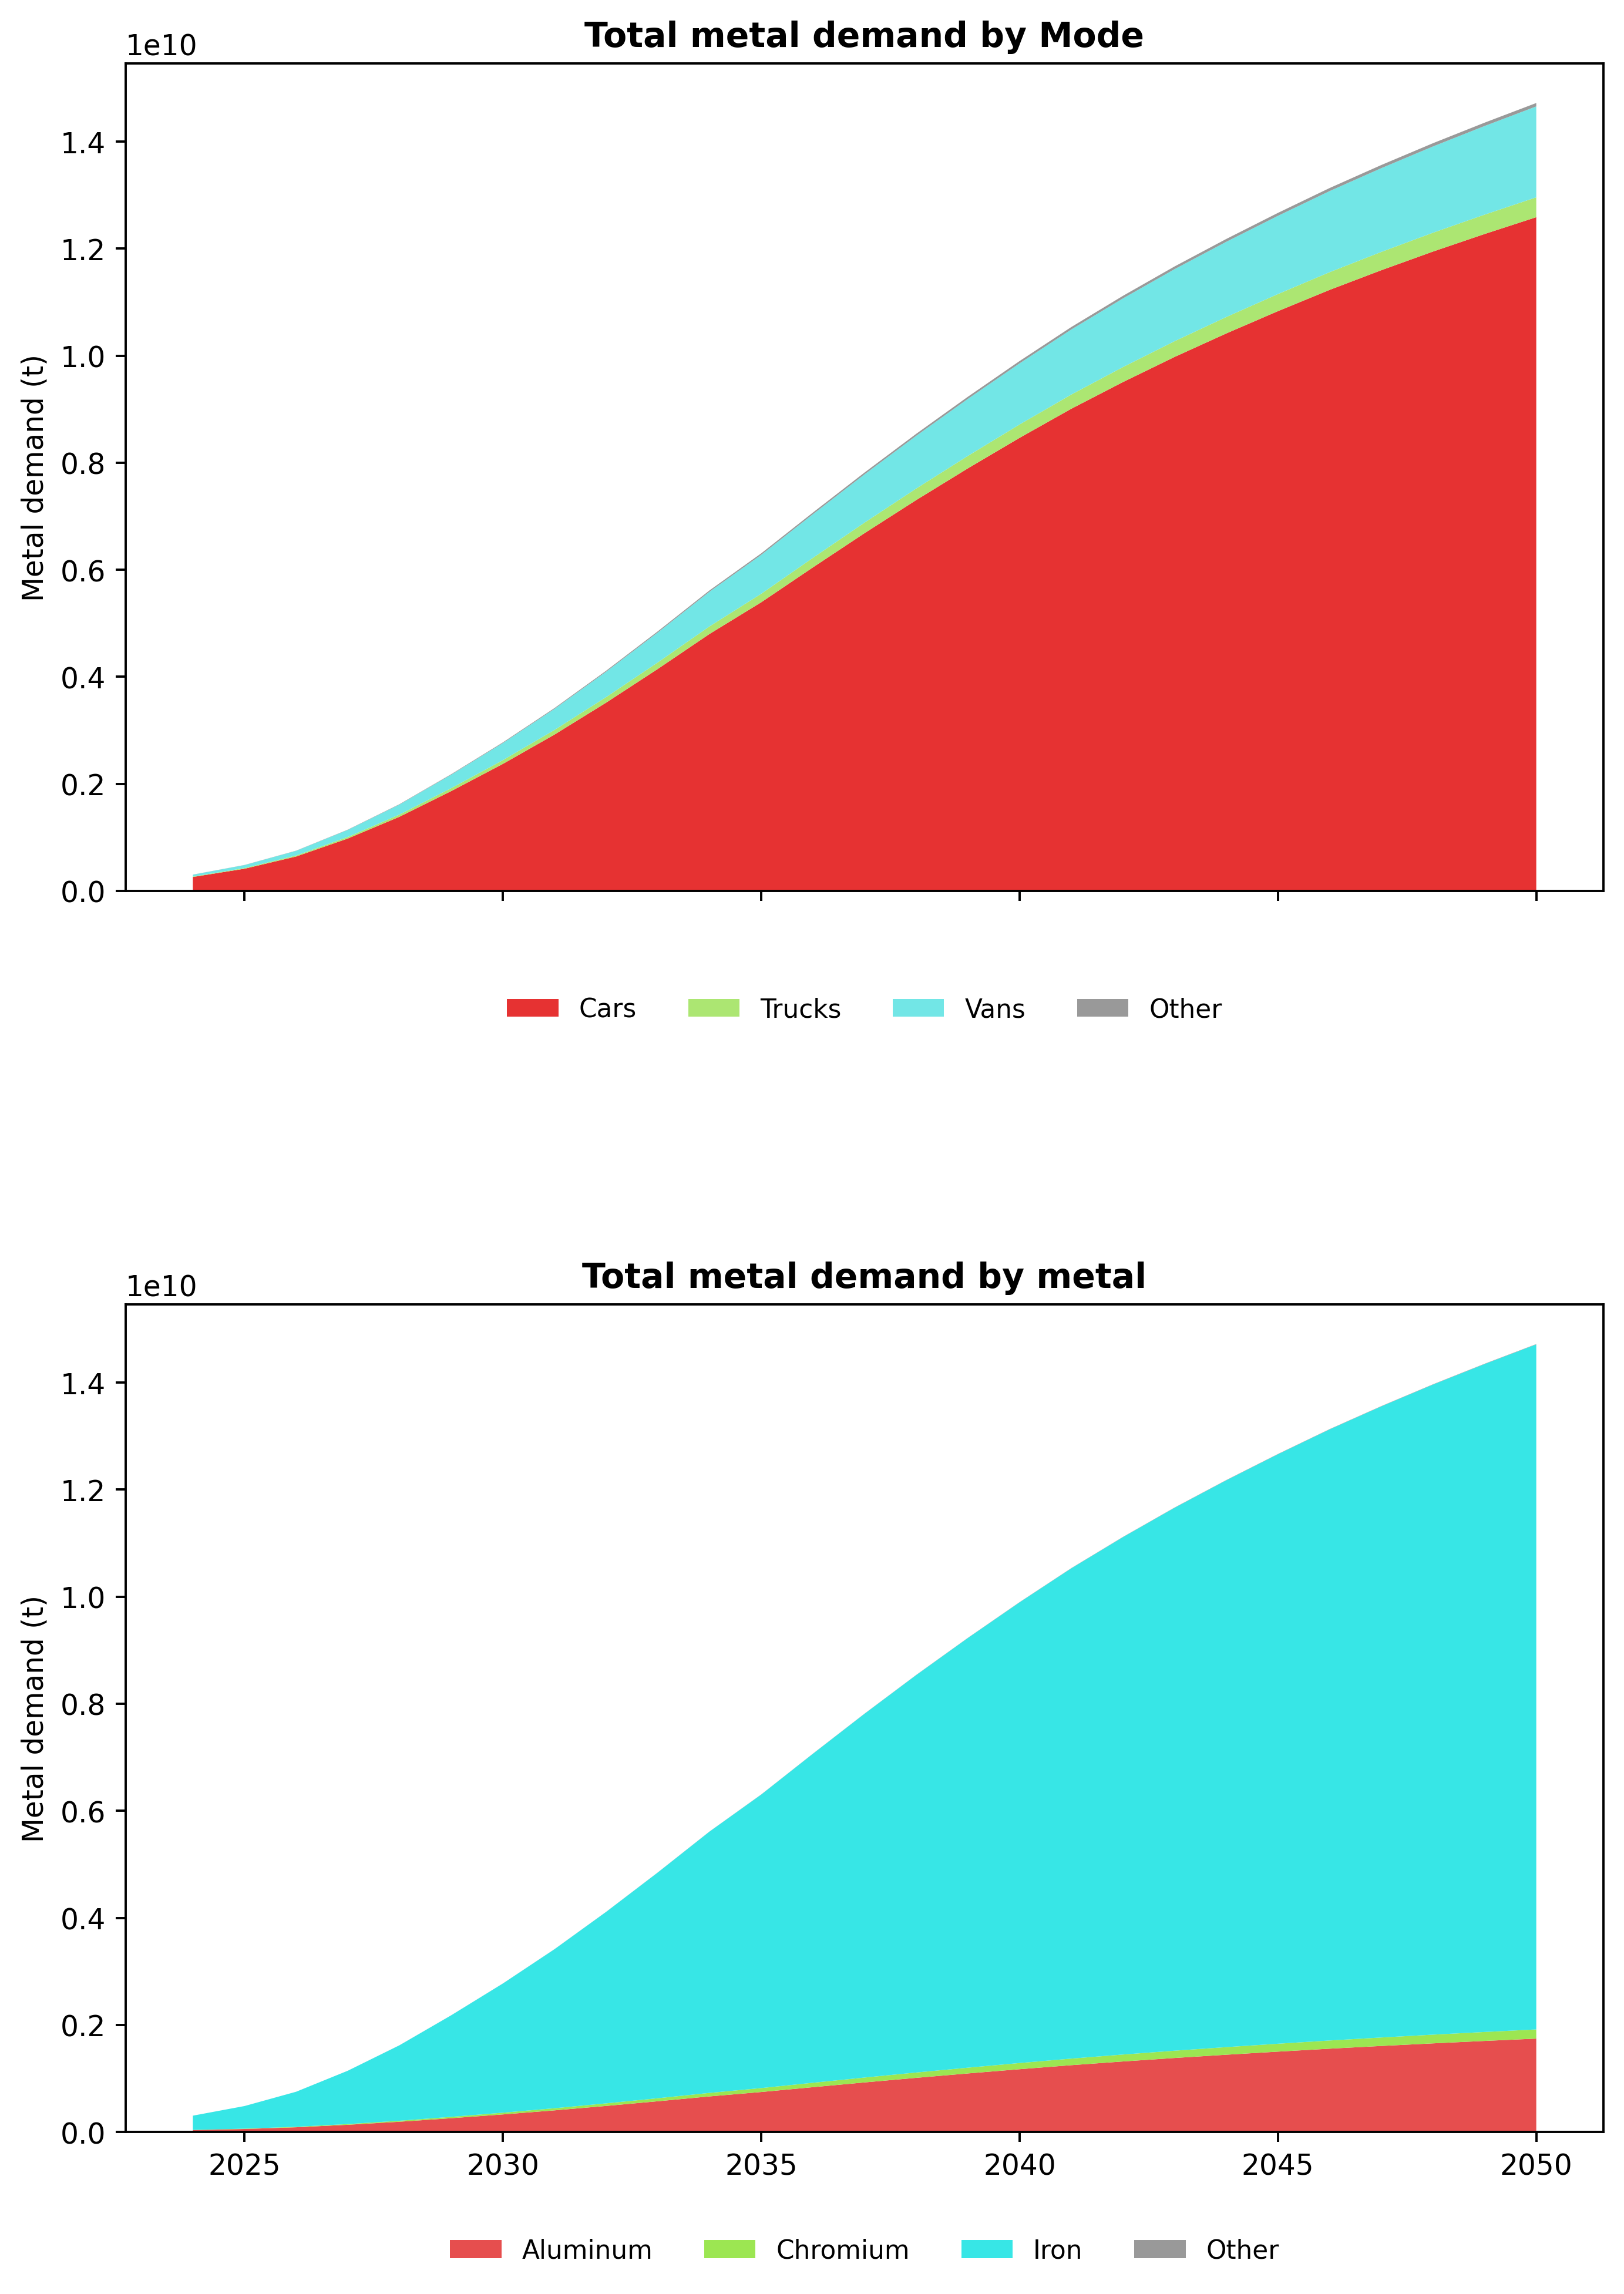

In [63]:
plot_metal_demand_stackplots(metal_demand_ev_body_nz, variable_col="Mode", savepath="results/EVs_body/metal_demand_ev_stackplot_by_mode")

# EVs - Battery motor

## Estimate material demand

In [64]:
mi_df_motor = mi_df[
    (mi_df['Technology'] == 'Vehicle motor') &
    (mi_df['Unit'] == 'g/vehicle')
]
mi_df_motor

,Technology,Sub-technology,Metal,Metal intensity,Unit,Reference,Fiability of the data,Comment
508,Vehicle motor,Ind,Copper,33673.5,g/vehicle,"(Månberger & Stenqvist, 2018)",No comparison,NaN
510,Vehicle motor,PM,Copper,13884.5,g/vehicle,"(Månberger & Stenqvist, 2018)",No comparison,NaN
514,Vehicle motor,PM,Dysprosium,83.0,g/vehicle,"(Watari et al., 2018)",Variability in data,NaN
517,Vehicle motor,PM,Neodymium,695.0,g/vehicle,"(Watari et al., 2018)",Small variability in data,NaN
518,Vehicle motor,PM,Praesodymium,1.0,g/vehicle,"(Watari et al., 2018)",No comparison,NaN


In [65]:
evs_body_mi_mapping = { # From Powertrain to Technology, Sub-technology
    "BEV": [("Vehicle motor, PM", 1.0)],
    "FCEV": [("Vehicle motor, PM", 1.0)],
    "PHEV": [("Vehicle motor, PM", 1.0)]
}

In [66]:
metal_demand_ev_motor = calculate_metal_demand_ev_body(projected_ev_sales_df, mi_df_motor, mapping_dict=evs_body_mi_mapping, main_var="EV_sales")

In [67]:
metal_demand_ev_motor_nz = metal_demand_ev_motor[metal_demand_ev_motor['Scenario'] == 'Canada Net-zero']
metal_demand_ev_motor_step = metal_demand_ev_motor[metal_demand_ev_motor['Scenario'] == 'Canada Current Measures']

In [68]:
metal_demand_ev_motor.to_csv(r'results/EVs_motor/metal_demand_ev_motor.csv', index=False)

## Plots

✅ Saved to results/EVs_motor/metal_demand_ev_facets_by_mode.png / .svg


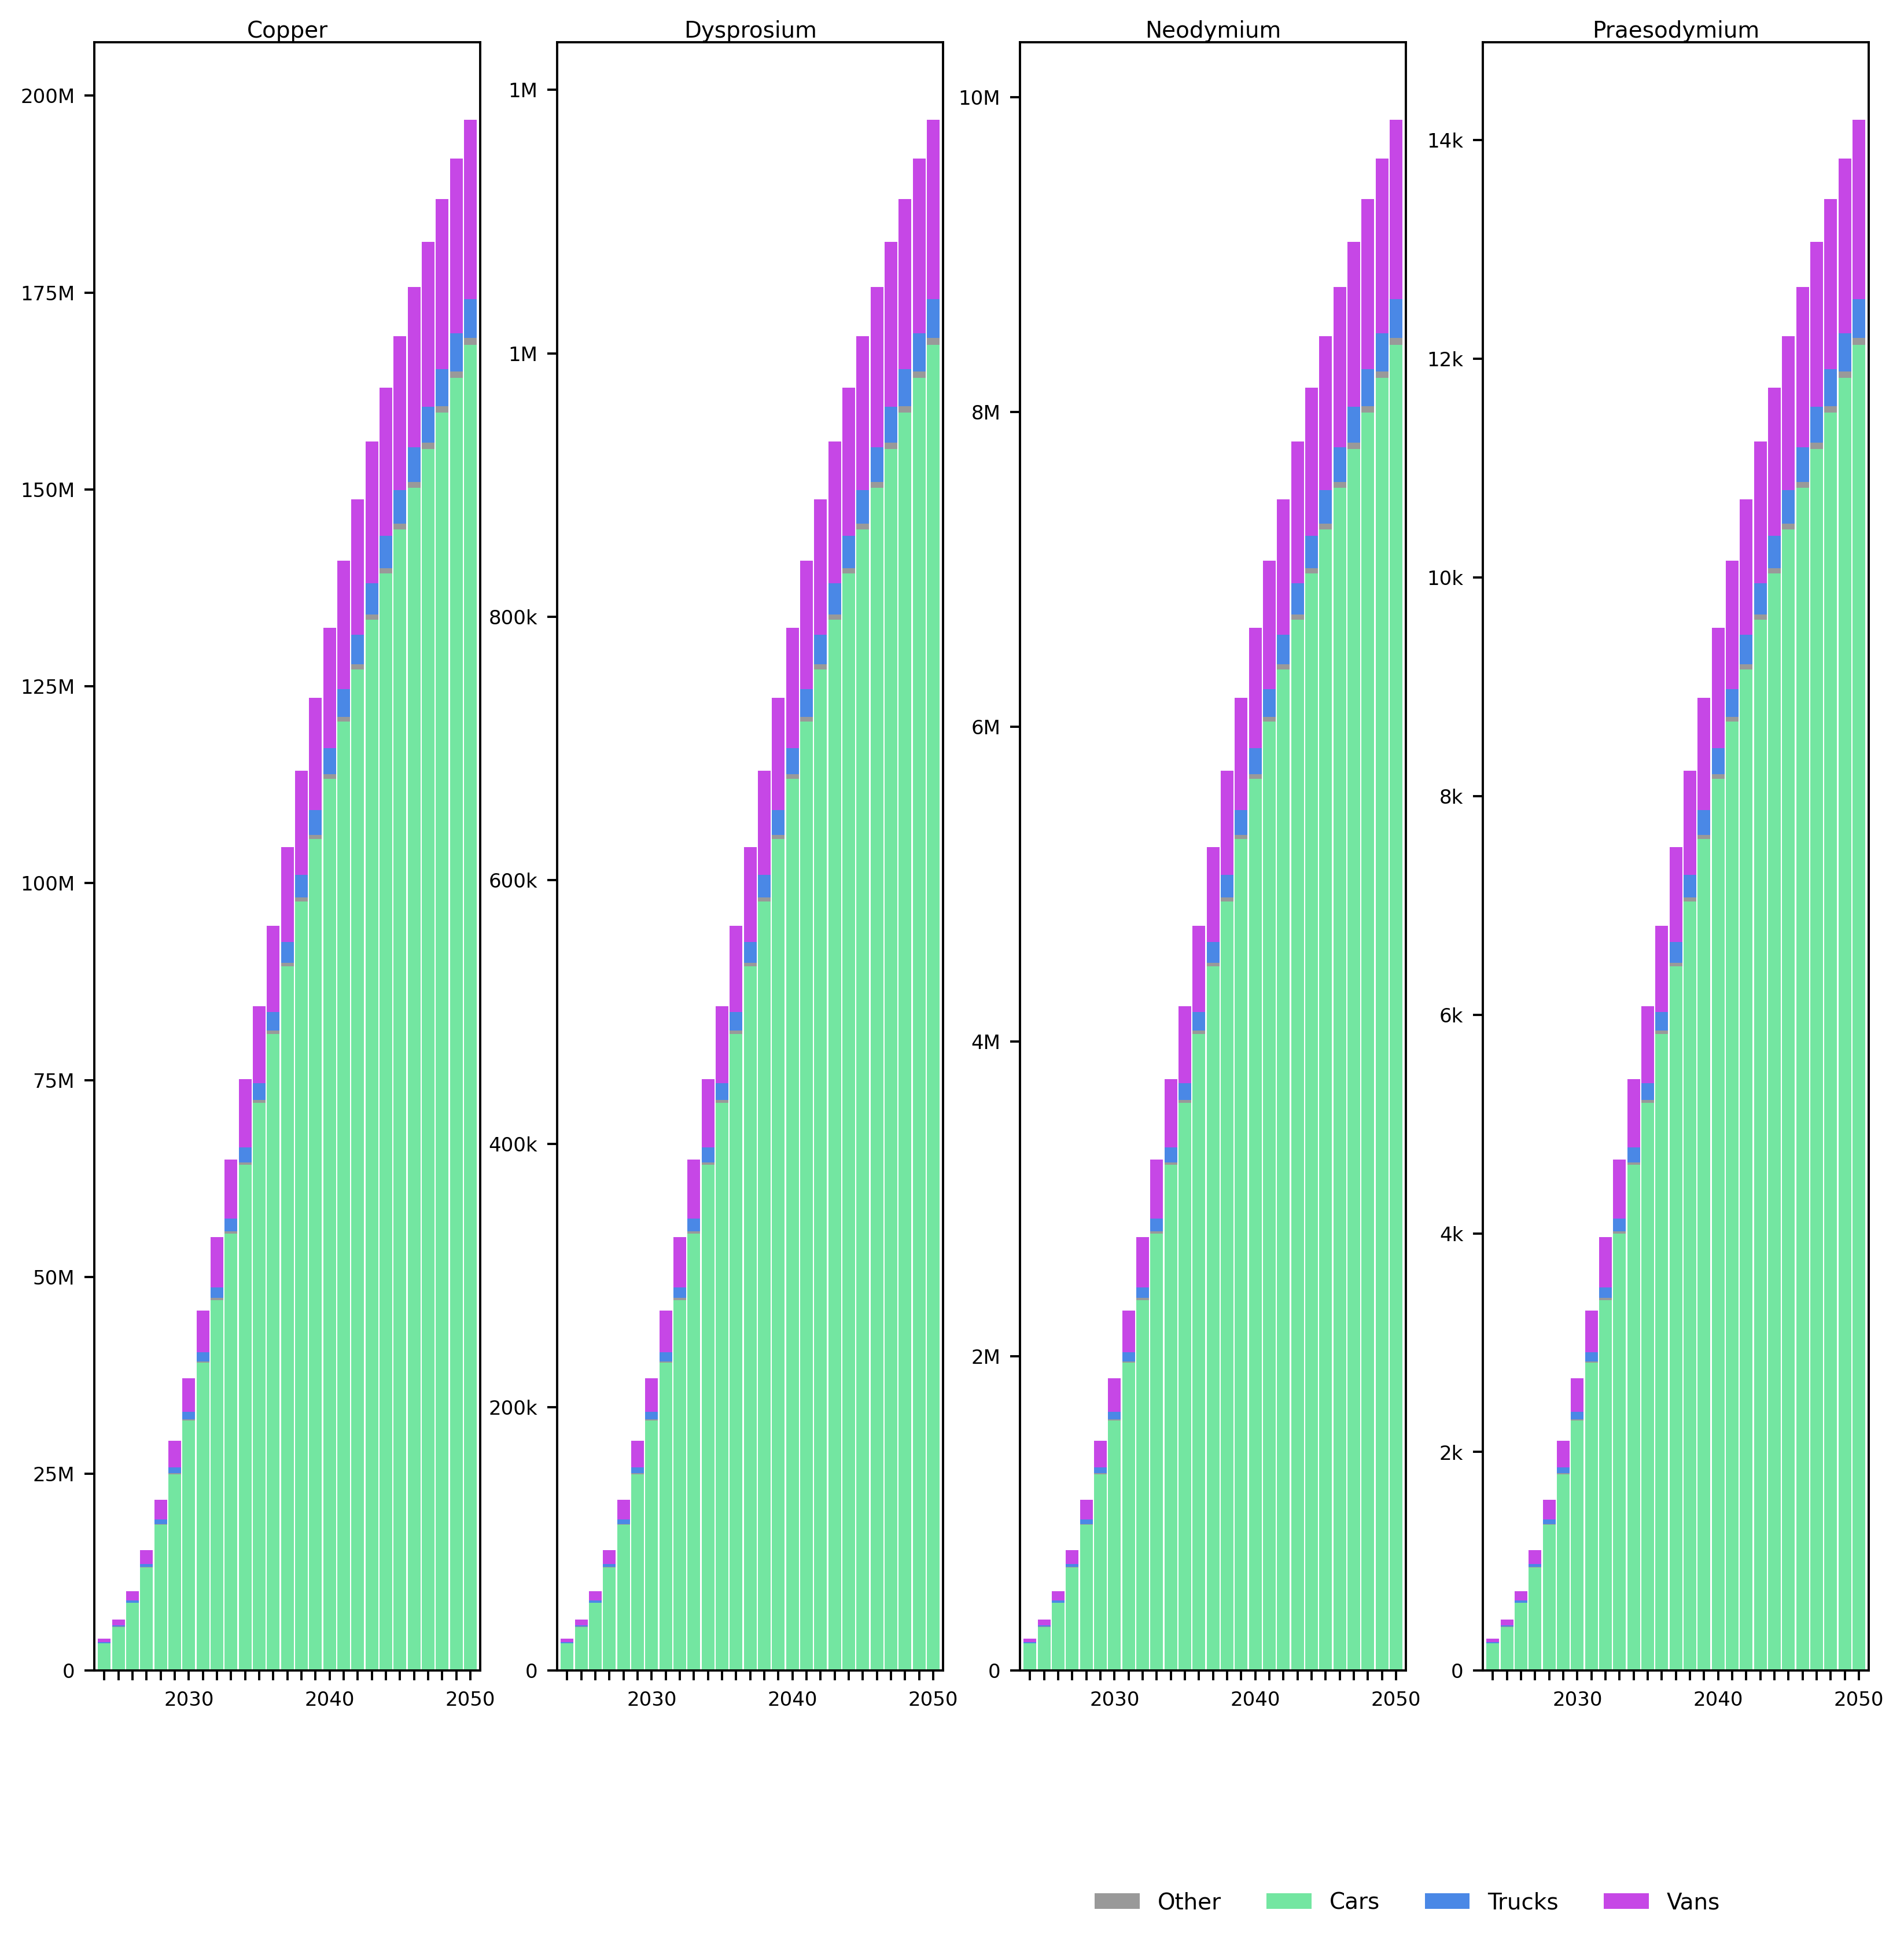

In [69]:
plot_metal_demand_facets(metal_demand_ev_motor_nz, variable_col='Mode', savepath="results/EVs_motor/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_motor/metal_demand_ev_stackplot_by_mode.png and .svg


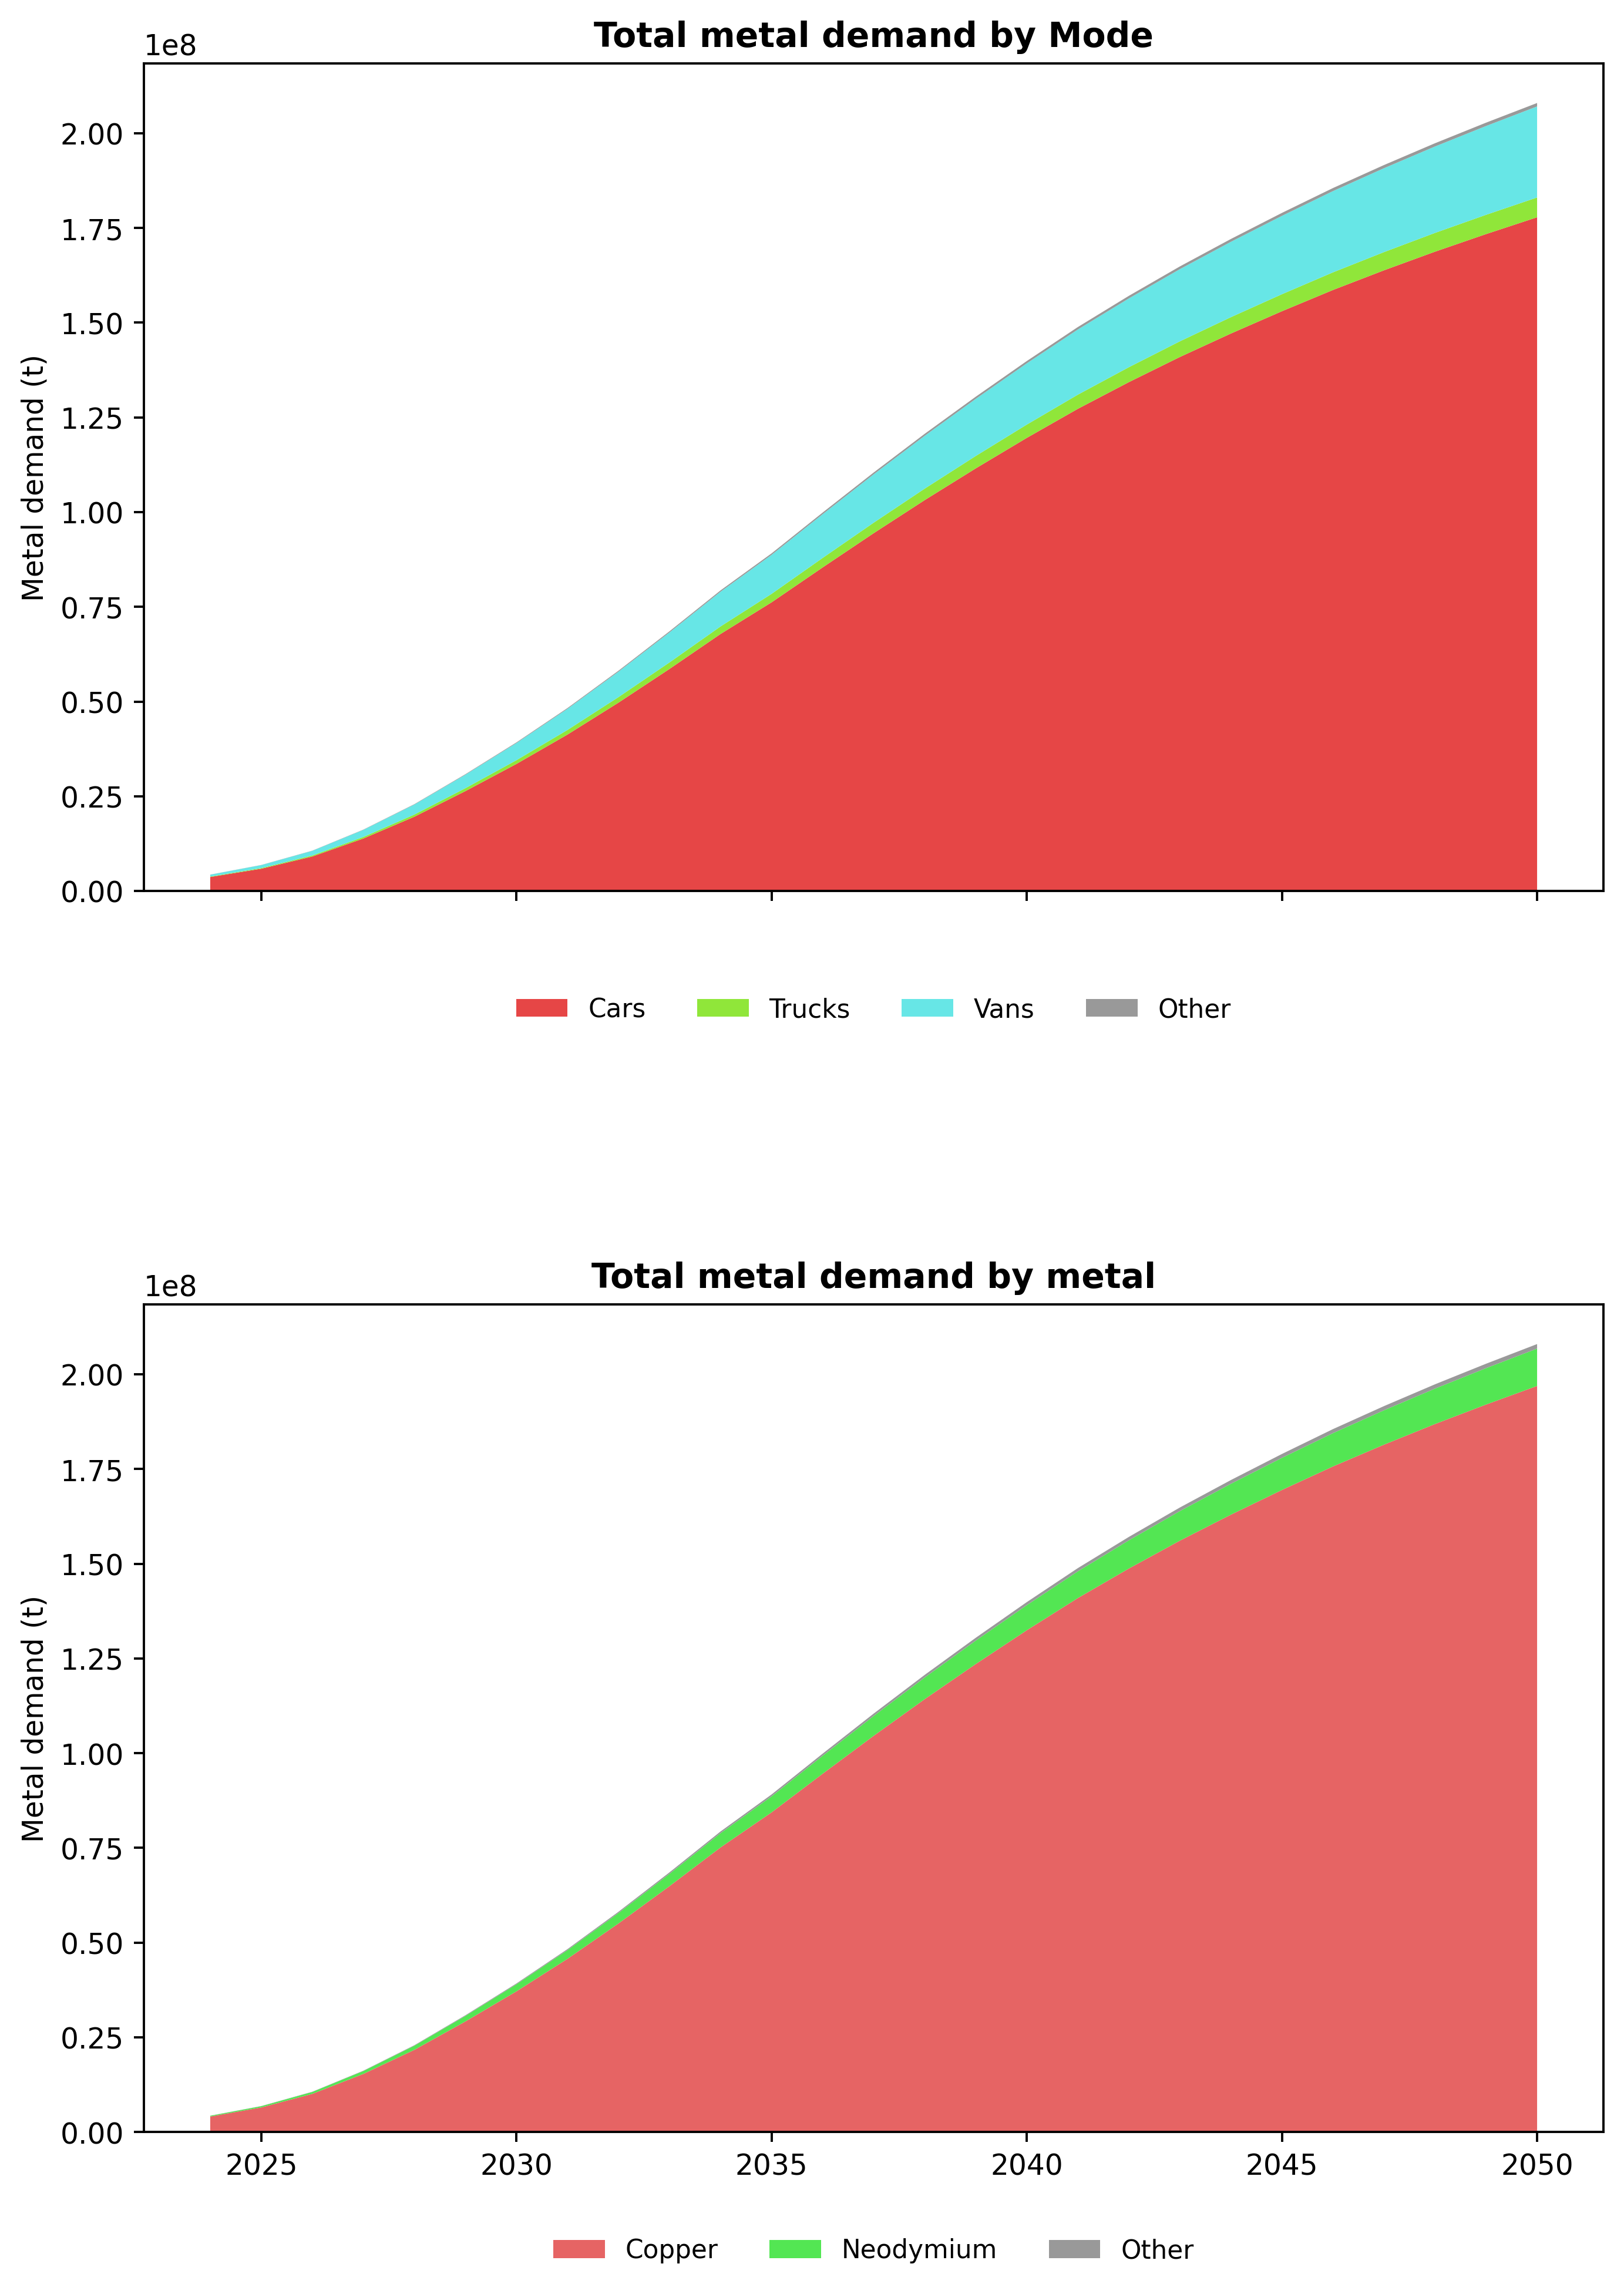

In [70]:
plot_metal_demand_stackplots(metal_demand_ev_motor_nz, variable_col="Mode", savepath="results/EVs_motor/metal_demand_ev_stackplot_by_mode")

# EVs - total

In [72]:
material_demand_ev_battery['Technology'] = 'Vehicle battery'

In [73]:
cols_to_keep = ['Country', 'Scenario', 'Year', 'Technology', 'Mode', 'Powertrain', 'Metal', 'Metal_demand_t']
material_demand_ev_battery_t = material_demand_ev_battery[cols_to_keep]
material_demand_ev_body_t = material_demand_ev_body[cols_to_keep]
material_demand_ev_motor_t = metal_demand_ev_motor[cols_to_keep]

In [74]:
# Put the 3 dfs in a single dfs
material_demand_ev = pd.concat([material_demand_ev_battery_t, material_demand_ev_body_t, material_demand_ev_motor_t], ignore_index=True)

In [75]:
metal_demand_ev = material_demand_ev[~material_demand_ev['Metal'].isin(non_metals)]
metal_demand_ev_nz = metal_demand_ev[metal_demand_ev['Scenario'] == 'Canada Net-zero']
metal_demand_ev_step = metal_demand_ev[metal_demand_ev['Scenario'] == 'Canada Current Measures']

In [76]:
material_demand_ev.to_csv(r'results/EVs/material_demand_ev.csv', index=False)

✅ Saved to results/EVs/metal_demand_ev_facets_by_mode.png / .svg


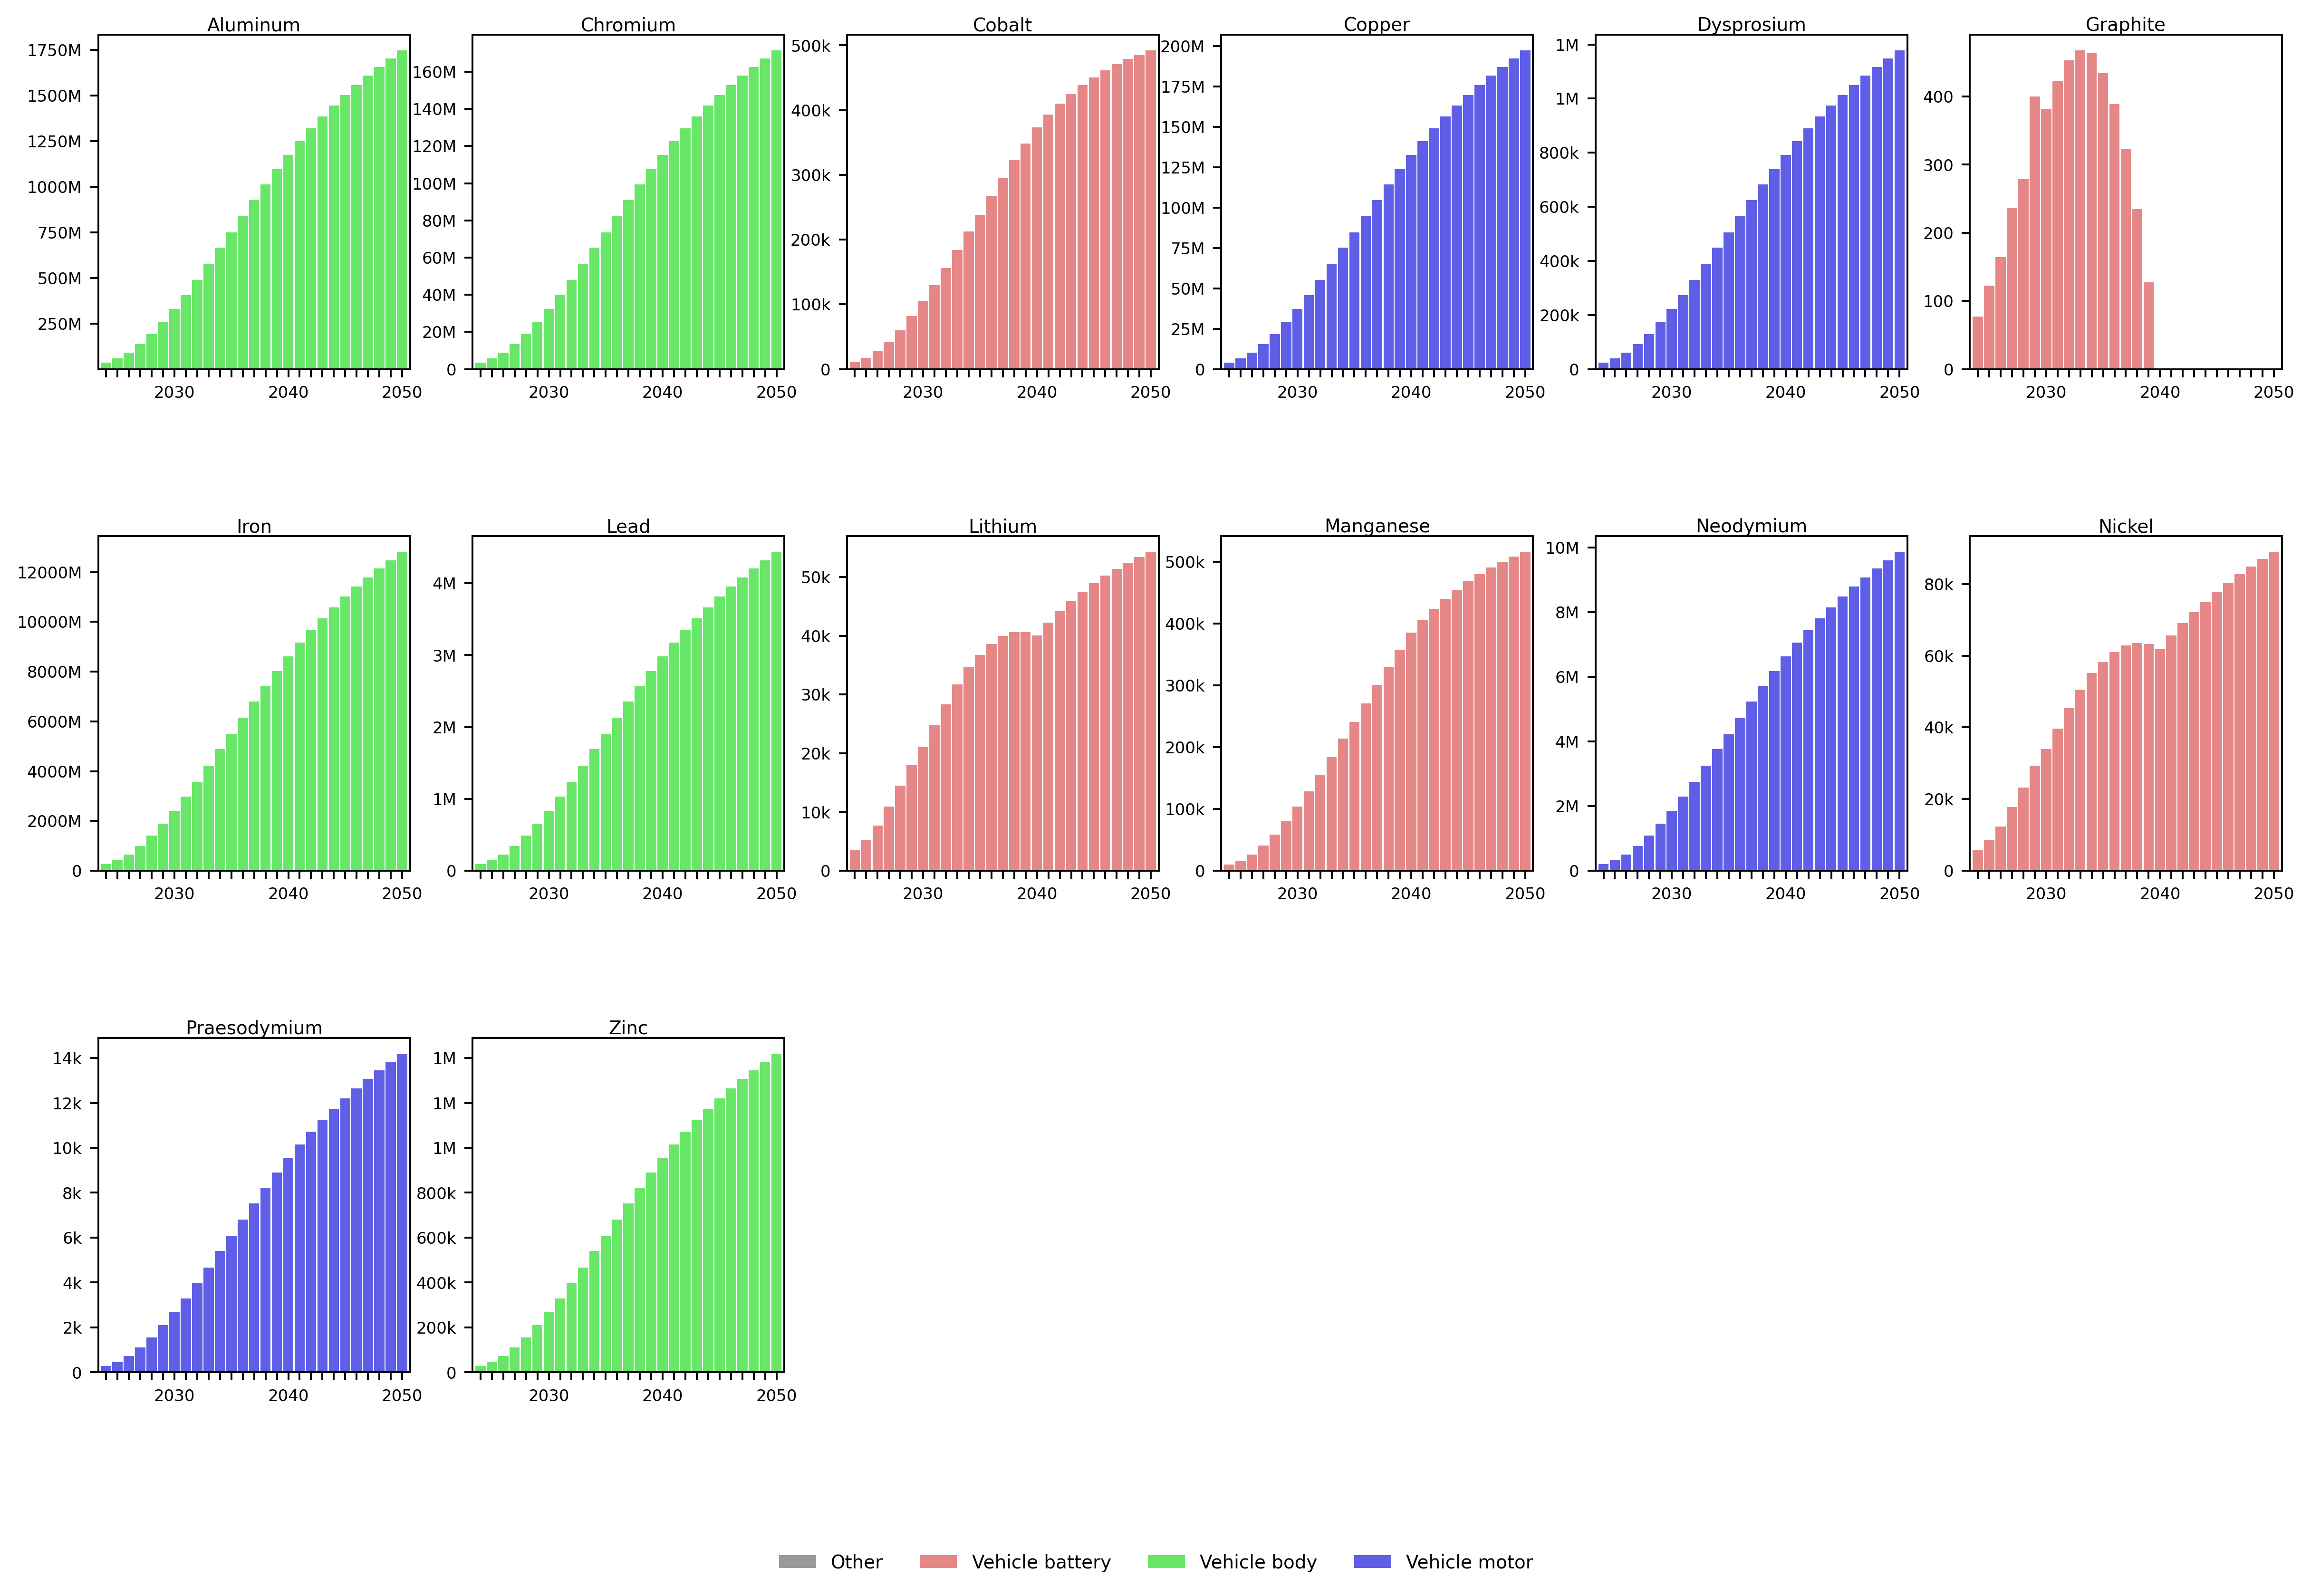

In [77]:
plot_metal_demand_facets(metal_demand_ev_nz, variable_col='Technology', savepath="results/EVs/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs/metal_demand_ev_stackplot_by_mode.png and .svg


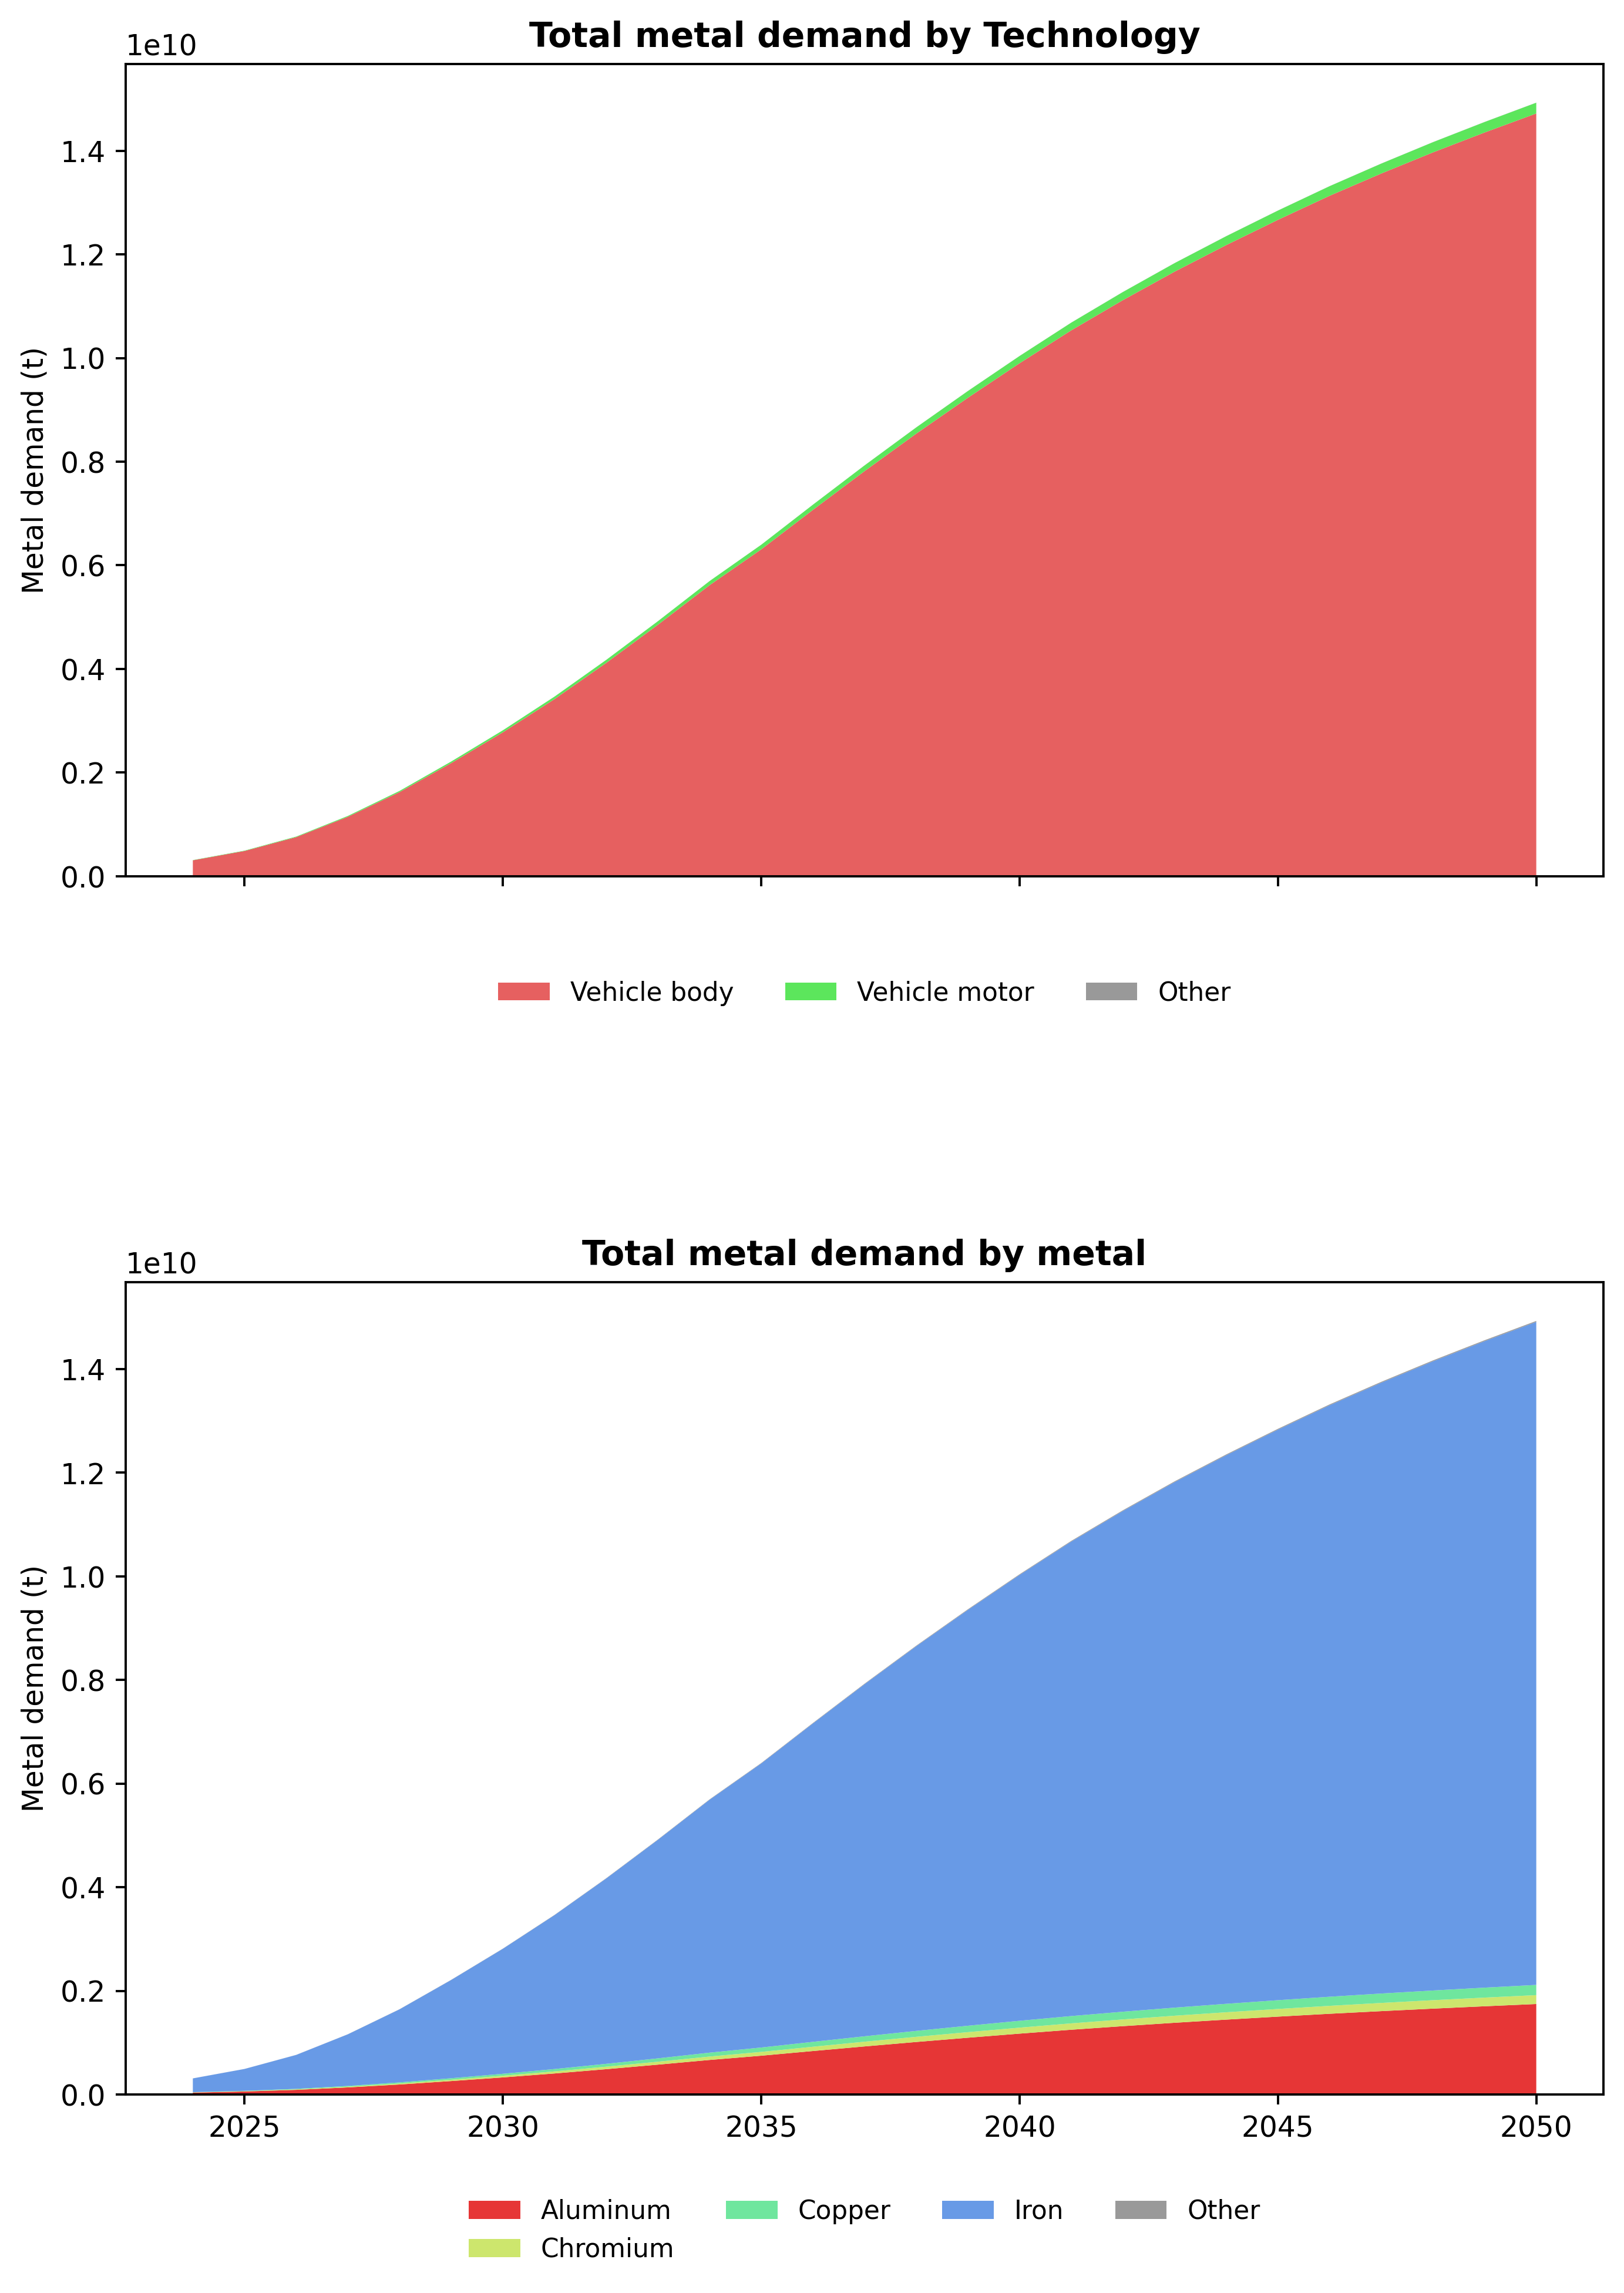

In [78]:
plot_metal_demand_stackplots(metal_demand_ev_nz, variable_col="Technology", savepath="results/EVs/metal_demand_ev_stackplot_by_mode")